# Subsample-search results — utility delta from the full-graph baseline

Every figure anchors against the **full-graph** classifier (trained and tested on the original DGL dataset, computed by `compute_baselines.py`). All deltas are `subsampled - full_graph`. The story we want to tell:

1. Per-config AUPRC / RecK gap to the full-graph baseline (per dataset, mean across the 5 models with std error bars).
2. Per-(model x config) AUPRC / RecK delta heatmap so it's clear no single model is hiding the gap.
3. Collective distribution of delta across models per config (boxplot).
4. M-cap ablation for forest_fire (M = 1 vs 2 vs infinity).
5. Structural fidelity per config (coverage, prior_shift, deg_ratio) and how it lines up with utility.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110})

HERE = Path(os.getcwd())
ART  = HERE / 'artifacts'
FIG  = ART / 'figs';  FIG.mkdir(exist_ok=True)

util   = pd.read_csv(ART / 'grid' / 'utility.csv')
struct = pd.read_csv(ART / 'grid' / 'structure.csv')
base   = pd.read_csv(ART / 'baselines.csv')

DATASETS = ['weibo']
MODELS   = ['GCN', 'GIN', 'GraphSAGE', 'XGBGraph', 'XGBoost']
METHOD_COLORS = {
    'forest_fire':   '#e74c3c',
    'rwr':           '#3498db',
    'metis':         '#27ae60',
    'uniform':       '#95a5a6',
    'bfs_partition': '#f39c12',
    'bfs_snowball':  '#9b59b6',
}
print('utility shape:', util.shape, '| structure shape:', struct.shape, '| baselines shape:', base.shape)

utility shape: (8575, 14) | structure shape: (1714, 28) | baselines shape: (188, 8)


## 1. Prevalence + baseline reference

Prevalence is what AUPRC / RecK collapse to under random guessing. The baseline row is what each model achieves when given the *full original graph* end-to-end (mean across 3 splits).

In [2]:
prev = struct.groupby('dataset')['pos_rate_source'].first().rename('prevalence')
baseline = (base.groupby(['dataset', 'model'])[['AUPRC', 'RecK', 'AUROC']]
                .mean().reset_index())

summary = baseline.pivot_table(index='dataset', columns='model', values='AUPRC')
summary['mean'] = summary.mean(axis=1)
summary = summary.join(prev)
print('--- AUPRC: full-graph baseline per (dataset, model), mean across models, prevalence ---')
print(summary.round(3))
print()
summary_r = baseline.pivot_table(index='dataset', columns='model', values='RecK')
summary_r['mean'] = summary_r.mean(axis=1)
summary_r = summary_r.join(prev)
print('--- RecK: full-graph baseline per (dataset, model), mean across models, prevalence ---')
print(summary_r.round(3))

--- AUPRC: full-graph baseline per (dataset, model), mean across models, prevalence ---
             GCN    GIN  GraphSAGE  XGBGraph  XGBoost   mean  prevalence
dataset                                                                 
amazon     0.356  0.788      0.633     0.927    0.906  0.722       0.092
questions  0.122  0.126      0.170     0.147    0.152  0.143       0.032
reddit     0.062  0.059      0.054     0.058    0.055  0.057       0.033
tfinance   0.748  0.627      0.314     0.892    0.804  0.677       0.046
tolokers   0.451  0.406      0.488     0.487    0.390  0.445       0.218
tsocial    0.161  0.095      0.134     0.924    0.151  0.293         NaN
weibo      0.946  0.912      0.850     0.974    0.950  0.926       0.103
yelp       0.218  0.369      0.555     0.866    0.833  0.568       0.146

--- RecK: full-graph baseline per (dataset, model), mean across models, prevalence ---
             GCN    GIN  GraphSAGE  XGBGraph  XGBoost   mean  prevalence
dataset              

In [3]:
# Build a single tidy frame: per (dataset, params_tag, method, model) joined with baseline
util_avg = (util.groupby(['dataset', 'method', 'params_tag', 'model'])
                [['AUROC', 'AUPRC', 'RecK']].mean().reset_index())
util_avg = util_avg.merge(
    baseline.rename(columns={'AUROC': 'AUROC_base',
                             'AUPRC': 'AUPRC_base',
                             'RecK':  'RecK_base'}),
    on=['dataset', 'model'])
util_avg['AUPRC_delta'] = util_avg['AUPRC'] - util_avg['AUPRC_base']
util_avg['RecK_delta']  = util_avg['RecK']  - util_avg['RecK_base']
util_avg.head()

,dataset,method,params_tag,model,AUROC,AUPRC,RecK,AUPRC_base,RecK_base,AUROC_base,AUPRC_delta,RecK_delta
0,amazon,bfs_partition,bfs_part_ts500_mn32,GCN,0.824511,0.345938,0.433696,0.356259,0.375000,0.823446,-0.010321,0.058696
1,amazon,bfs_partition,bfs_part_ts500_mn32,GIN,0.906836,0.729746,0.675000,0.787748,0.711957,0.940778,-0.058002,-0.036957
2,amazon,bfs_partition,bfs_part_ts500_mn32,GraphSAGE,0.879601,0.666637,0.639130,0.633085,0.658696,0.873208,0.033551,-0.019565
3,amazon,bfs_partition,bfs_part_ts500_mn32,XGBGraph,0.983832,0.921870,0.877174,0.926889,0.861957,0.988545,-0.005019,0.015217
4,amazon,bfs_partition,bfs_part_ts500_mn32,XGBoost,0.978527,0.912575,0.871739,0.905871,0.853261,0.977670,0.006704,0.018478


## 2. Headline — AUPRC delta from full-graph baseline

Each bar = one config. Y-axis = AUPRC mean across 5 models, minus the full-graph mean for that dataset. **0 = full-graph performance**. Negative = utility lost via subsampling, positive = gained.

Error bars: standard deviation of the per-model deltas (5 models).

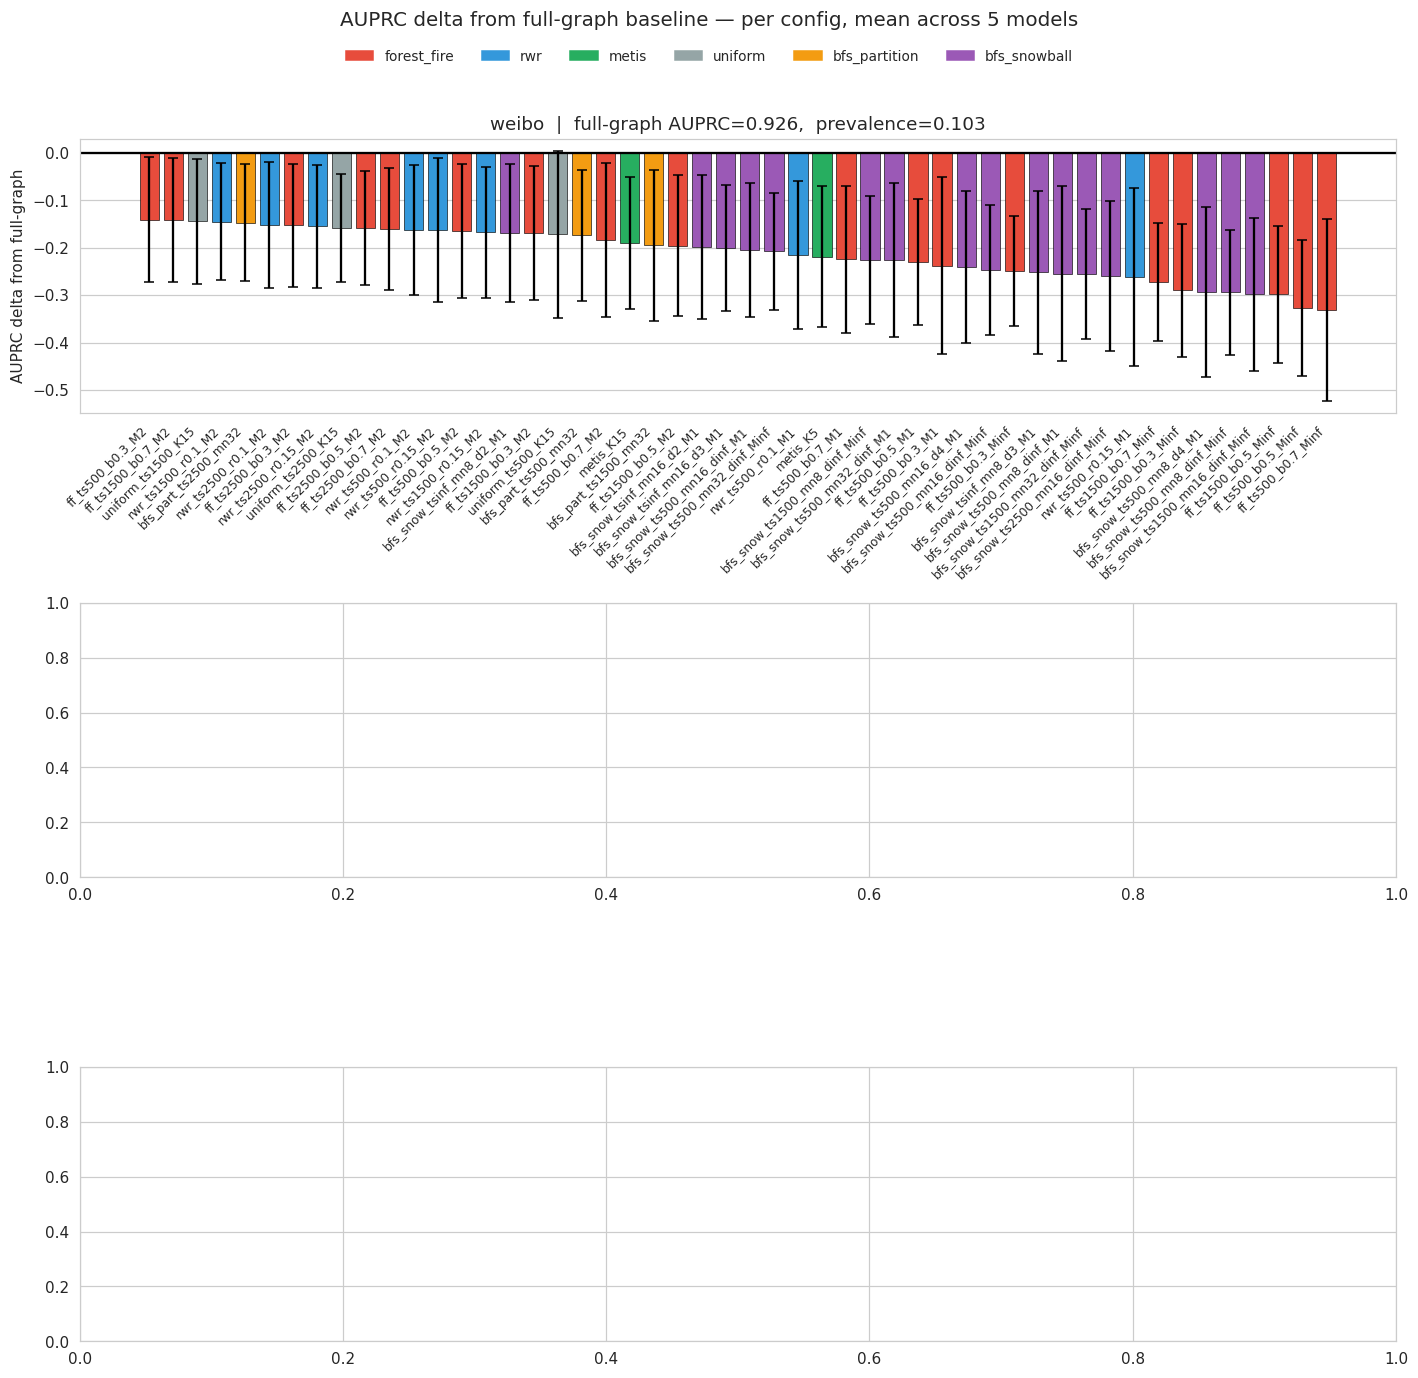

In [4]:
def _delta_panel(metric_delta_col, metric_name, util_avg, baseline, prev, ds, ax):
    sub = util_avg[util_avg['dataset'] == ds]
    cfg_mean = (sub.groupby(['params_tag', 'method'])[metric_delta_col]
                   .mean().reset_index()
                   .sort_values(metric_delta_col, ascending=False))
    cfg_std = sub.groupby('params_tag')[metric_delta_col].std().to_dict()

    colors = [METHOD_COLORS[m] for m in cfg_mean['method']]
    yerr = [cfg_std.get(t, 0.0) for t in cfg_mean['params_tag']]
    ax.bar(range(len(cfg_mean)), cfg_mean[metric_delta_col],
           yerr=yerr, color=colors, capsize=3,
           edgecolor='black', linewidth=0.4)
    ax.axhline(0, color='black', linewidth=1.5)
    base_val = baseline[baseline['dataset'] == ds][metric_name].mean()
    p = float(prev[ds])
    ax.set_xticks(range(len(cfg_mean)))
    ax.set_xticklabels(cfg_mean['params_tag'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(f'{metric_name} delta from full-graph')
    ax.set_title(f'{ds}  |  full-graph {metric_name}={base_val:.3f},  prevalence={p:.3f}')
    ax.grid(axis='x', visible=False)

fig, axes = plt.subplots(3, 1, figsize=(13, 12))
for ax, ds in zip(axes, DATASETS):
    _delta_panel('AUPRC_delta', 'AUPRC', util_avg, baseline, prev, ds, ax)

handles = [mpatches.Patch(color=c, label=m) for m, c in METHOD_COLORS.items()]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(METHOD_COLORS), fontsize=9, frameon=False)
fig.suptitle('AUPRC delta from full-graph baseline — per config, mean across 5 models',
             y=1.04, fontsize=13)
plt.tight_layout()
fig.savefig(FIG / 'auprc_delta_per_config.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Headline — RecK delta from full-graph baseline

Same shape as section 2 but for RecK (recall at K, where K = number of test positives). Reading: positive = recovers more true anomalies than the full-graph classifier; negative = misses some.

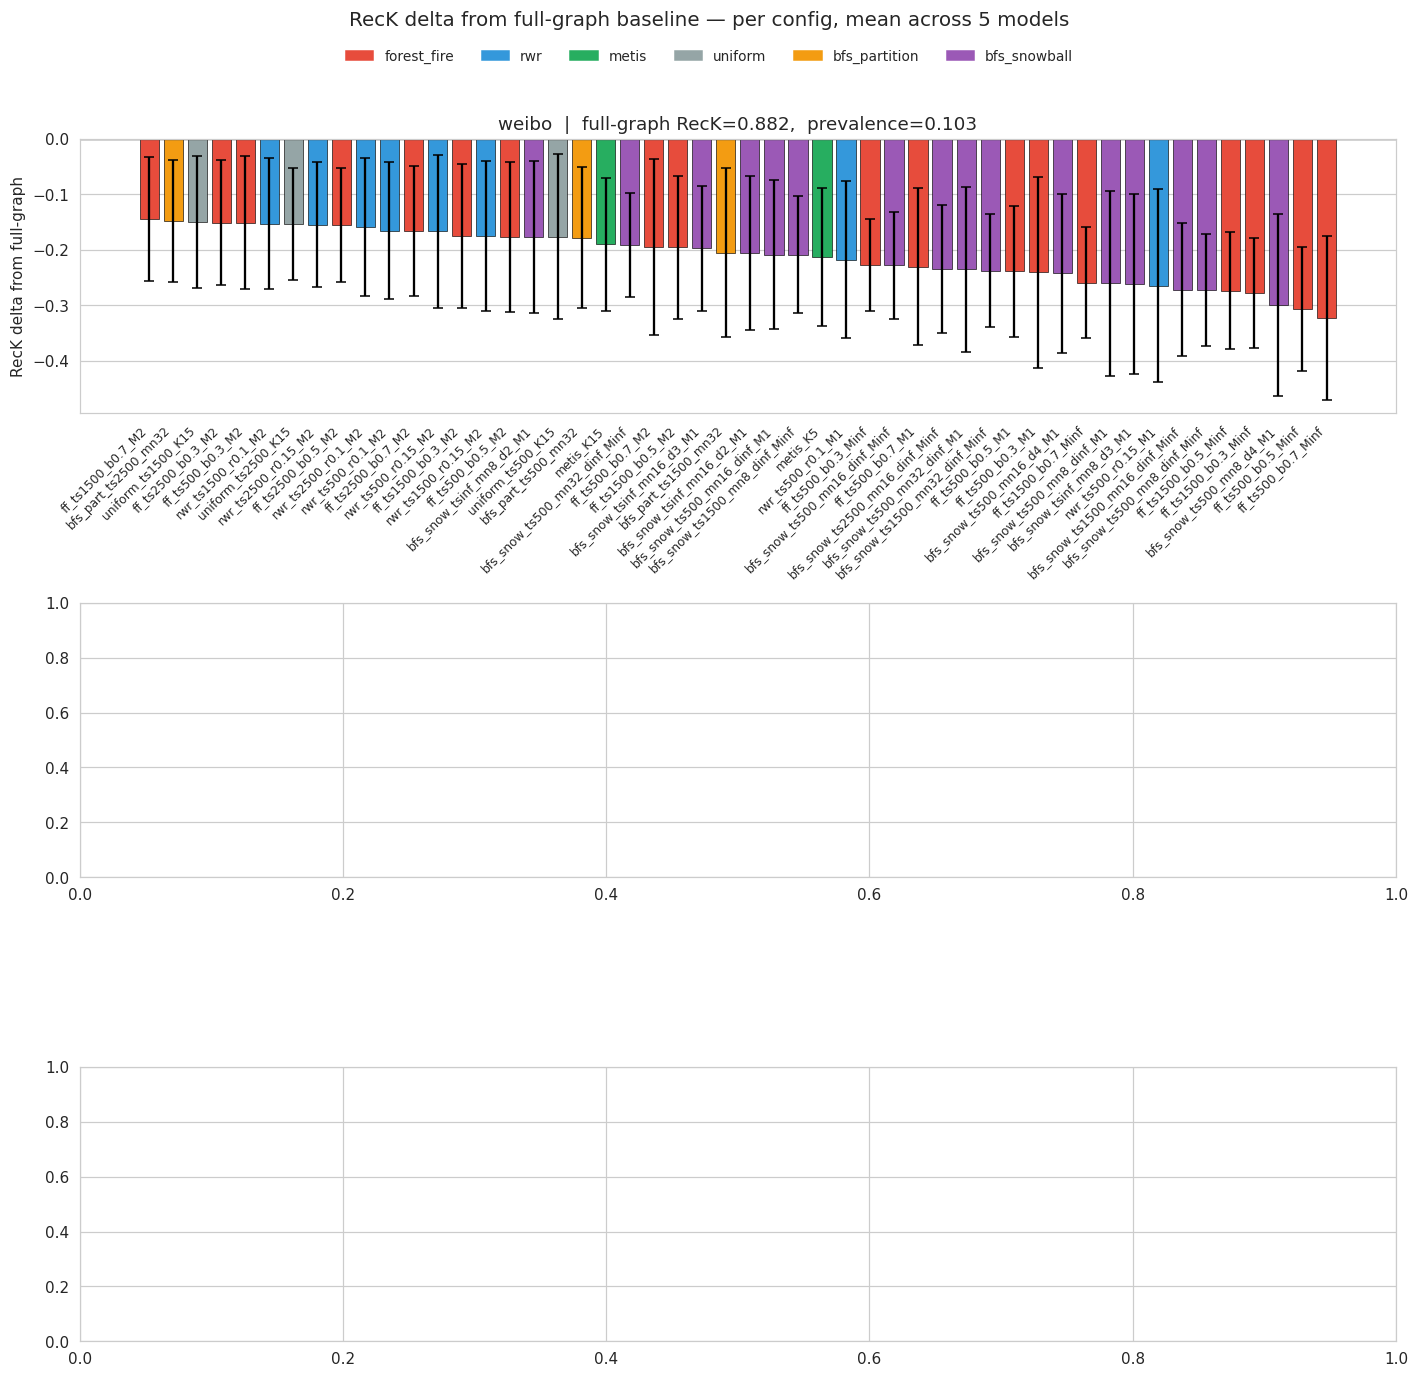

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
for ax, ds in zip(axes, DATASETS):
    _delta_panel('RecK_delta', 'RecK', util_avg, baseline, prev, ds, ax)

handles = [mpatches.Patch(color=c, label=m) for m, c in METHOD_COLORS.items()]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(METHOD_COLORS), fontsize=9, frameon=False)
fig.suptitle('RecK delta from full-graph baseline — per config, mean across 5 models',
             y=1.04, fontsize=13)
plt.tight_layout()
fig.savefig(FIG / 'reck_delta_per_config.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-(model x config) delta heatmap

Same data as sections 2-3 but broken out by model — confirms which configs are uniform improvements vs which only help certain models. Centered colormap: green = above full-graph, red = below.

Each cell annotates `mean\n(±std)` across the 3 splits (per-split delta = subsampled split — full-graph baseline on the *same* split, so split effects cancel before averaging). Wide std relative to the mean means the config's recovery is split-fragile.

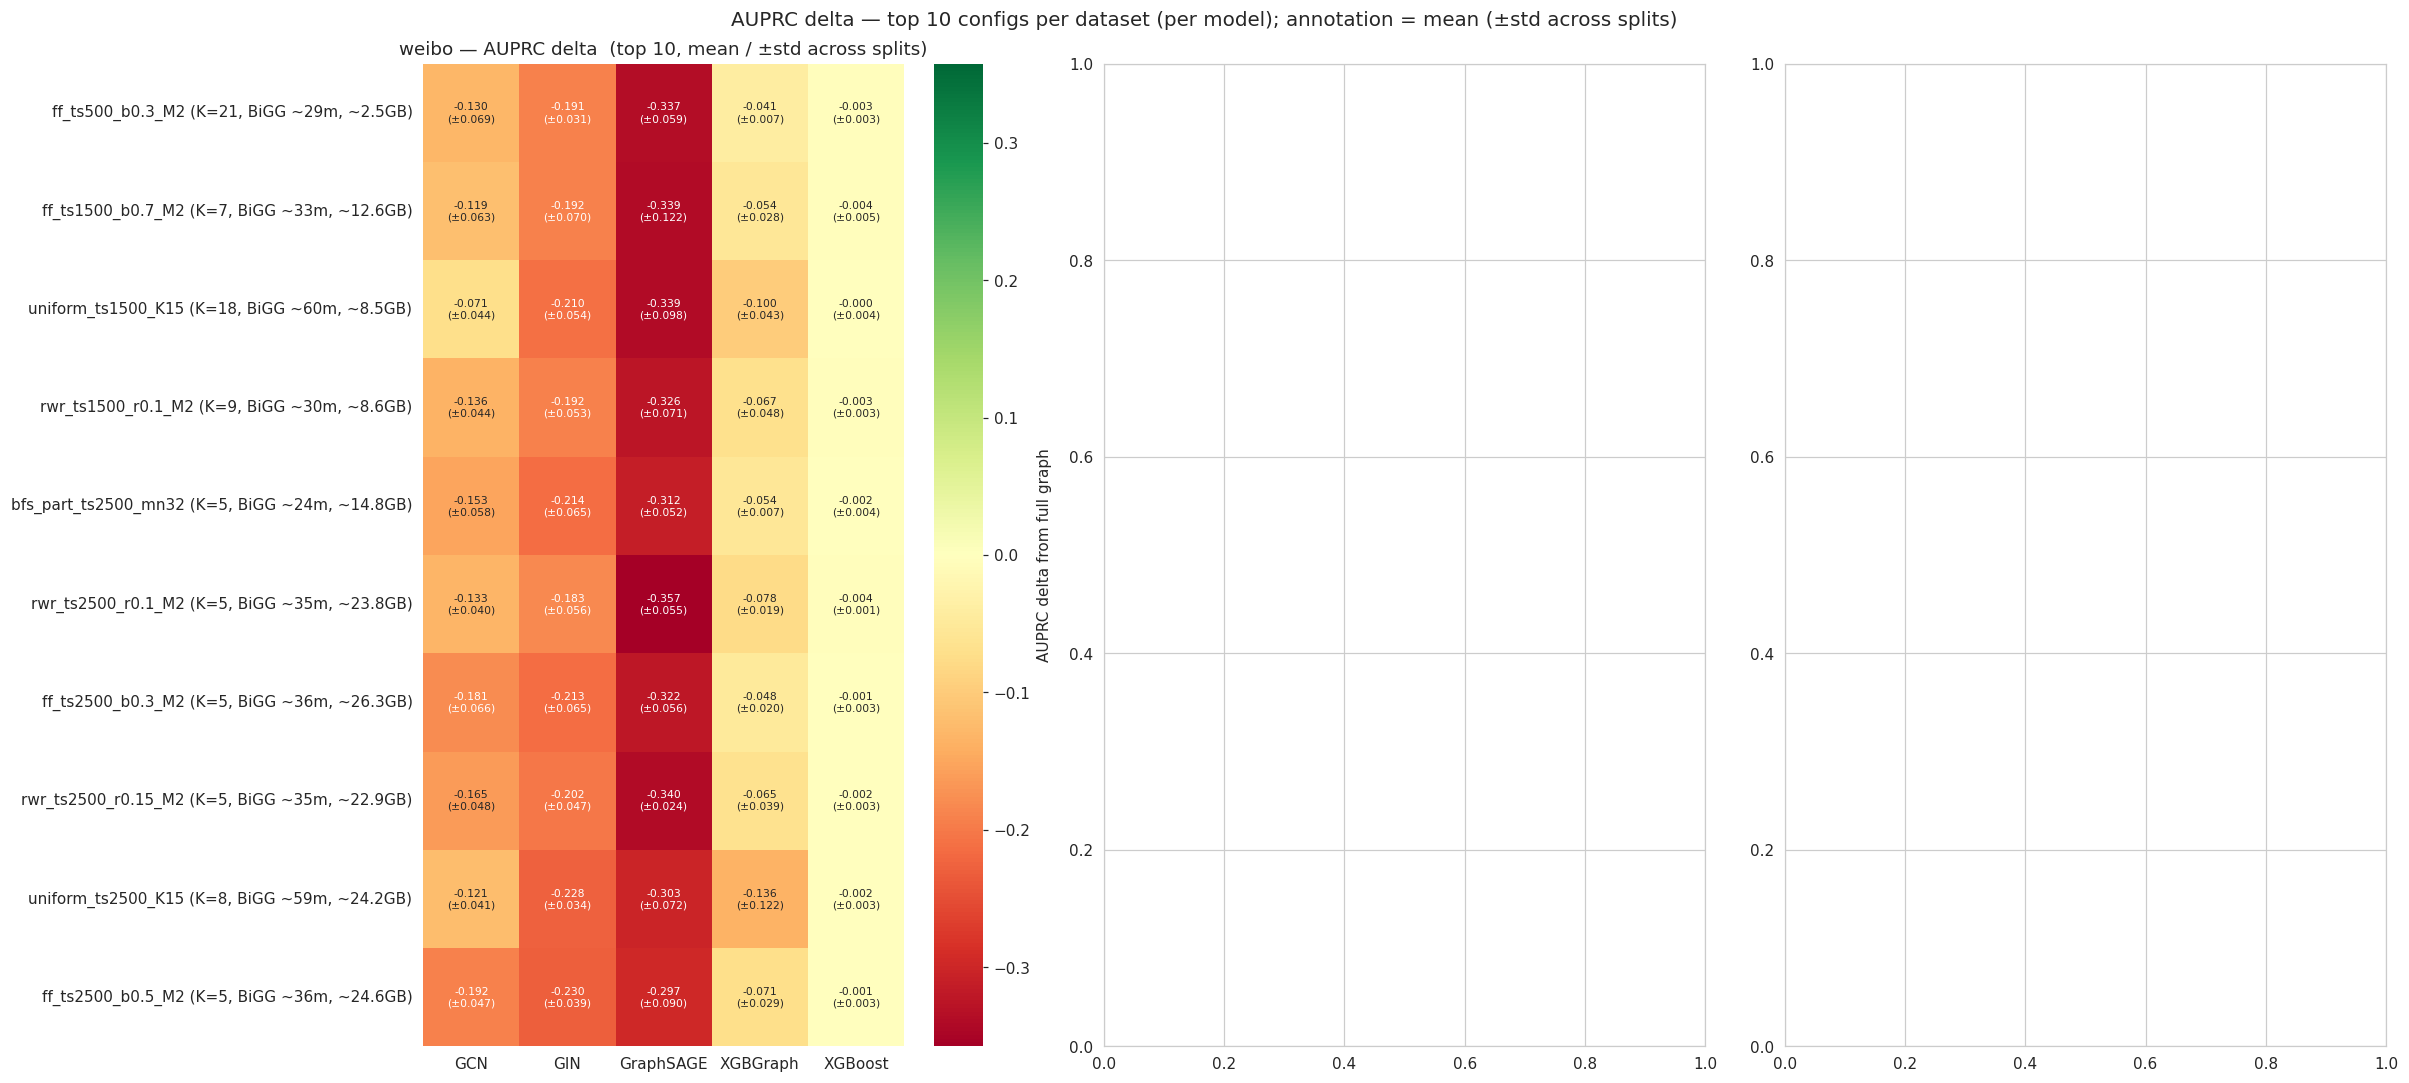

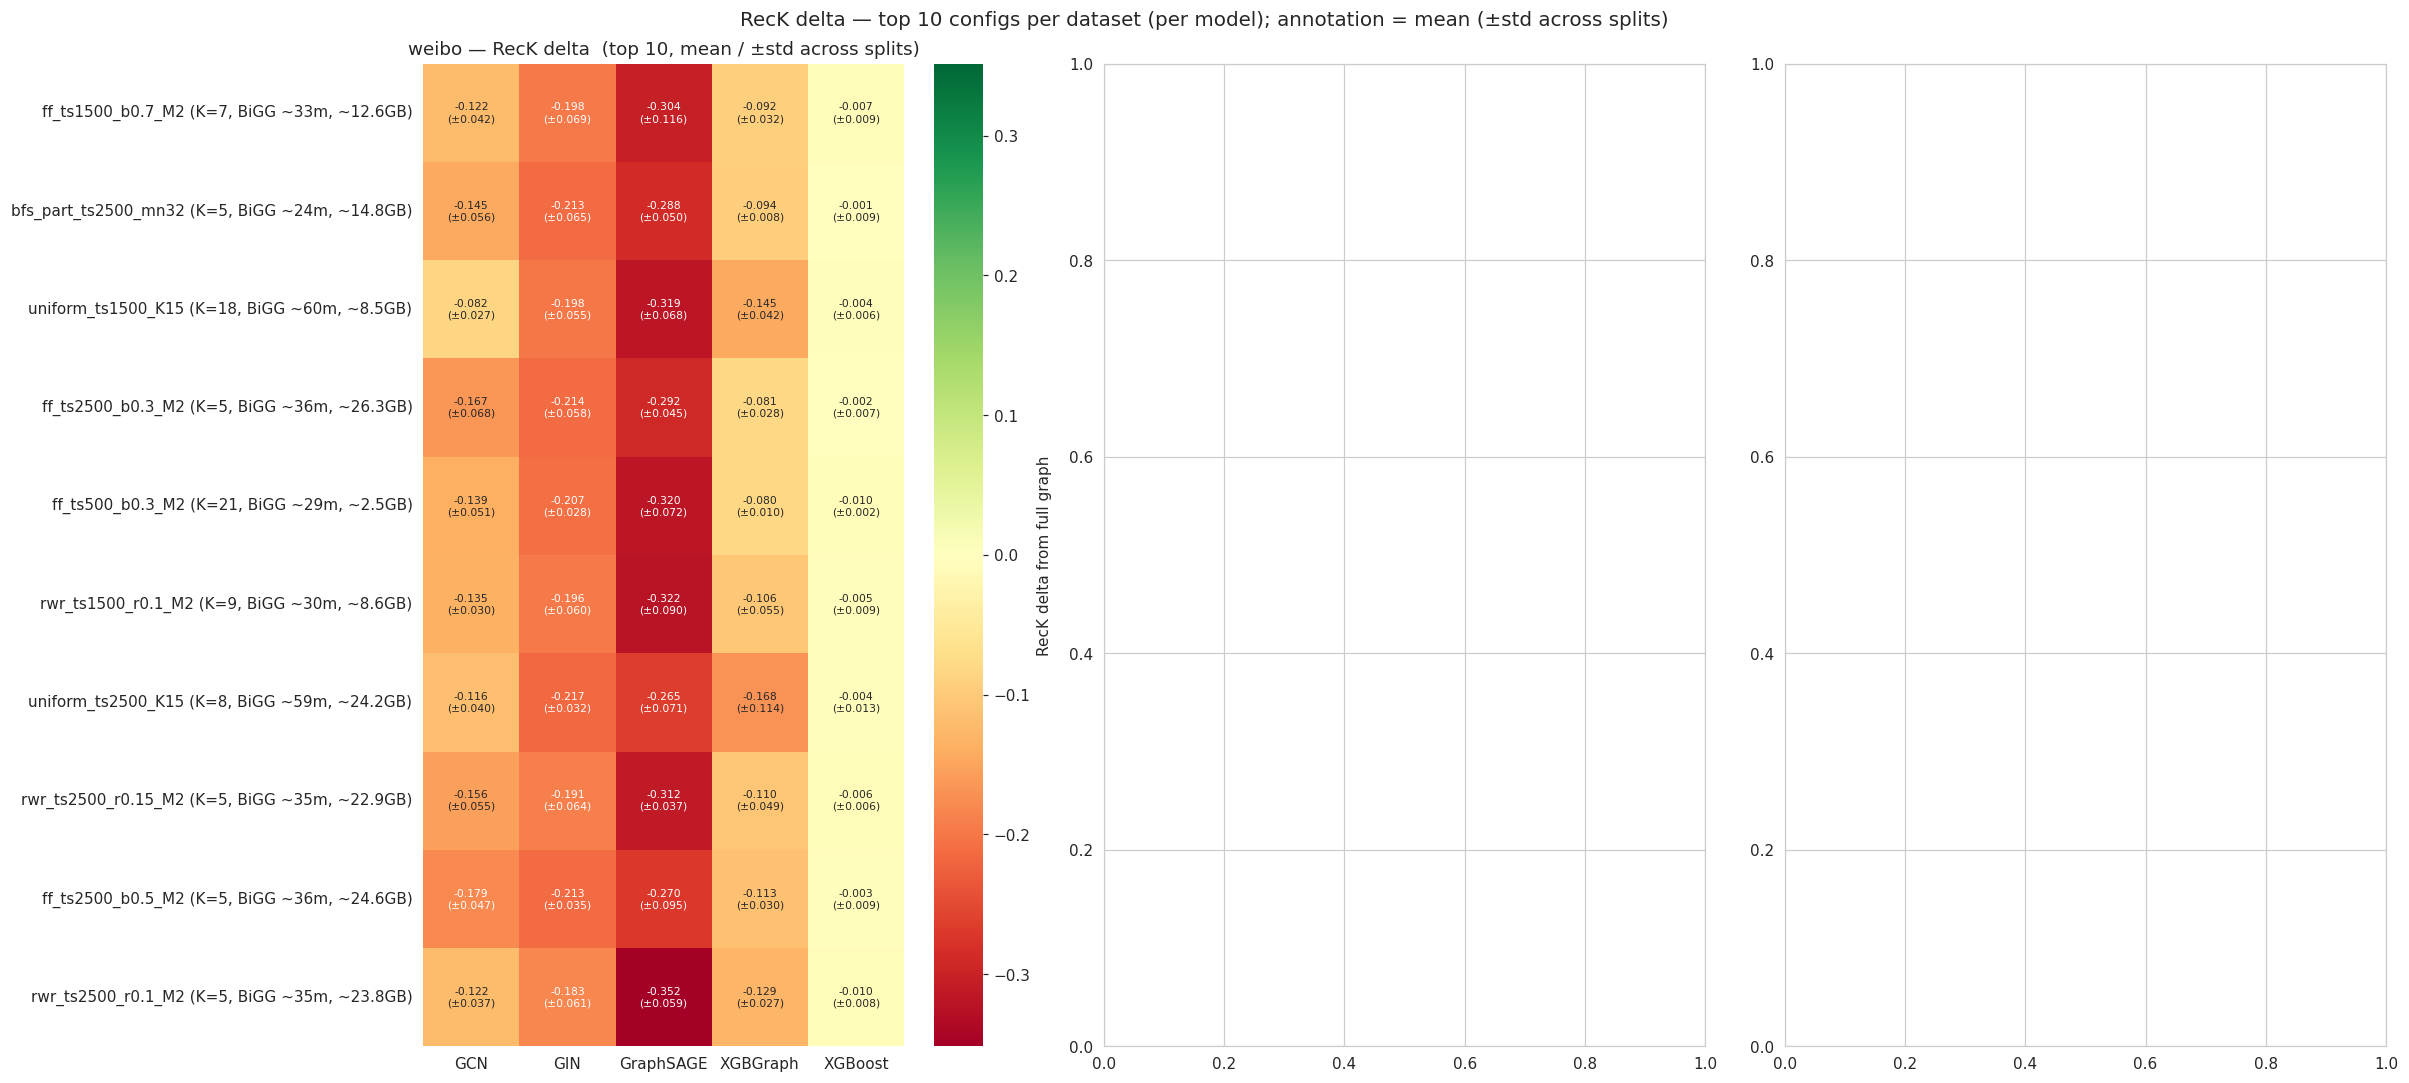

In [6]:
# Per-split deltas: subtract the matching split's full-graph baseline so split effects cancel.
util_split = util.merge(
    base[['dataset', 'model', 'split_id', 'AUPRC', 'RecK']]
        .rename(columns={'AUPRC': 'AUPRC_base', 'RecK': 'RecK_base'}),
    on=['dataset', 'model', 'split_id'])
util_split['AUPRC_delta'] = util_split['AUPRC'] - util_split['AUPRC_base']
util_split['RecK_delta']  = util_split['RecK']  - util_split['RecK_base']

TOP_K = 10  # show only the K best configs per dataset (ranked by mean delta across models)

# ---- Per-(dataset, params_tag) y-axis labels: append K, est BiGG wall-clock, est peak VRAM ----
import sys, importlib
_NB_DIR = str(HERE)
if _NB_DIR not in sys.path:
    sys.path.insert(0, _NB_DIR)
import cost_model  # noqa: E402
importlib.reload(cost_model)  # pick up edits without restarting the kernel
_cost = cost_model.fit_cost_model()

_cell_stats = (struct.groupby(['dataset', 'params_tag'])
                     .agg(K=('num_subgraphs', 'mean'),
                          edges_sum=('total_edges', 'sum'),
                          sg_sum=('num_subgraphs', 'sum'))
                     .reset_index())
_cell_stats['avg_m'] = _cell_stats['edges_sum'] / _cell_stats['sg_sum']

def _bigg_label(row):
    per_sg = _cost.predict_per_sg_total(row['dataset'], row['avg_m'])
    vram_gb = _cost.predict_peak_vram_gb(row['dataset'], row['avg_m'])
    K = row['K']
    if per_sg is None or pd.isna(K):
        return row['params_tag']
    total_min = K * per_sg / 60
    t = f'{total_min:.0f}m' if total_min < 60 else f'{total_min/60:.1f}h'
    v = f', ~{vram_gb:.1f}GB' if vram_gb is not None else ''
    return f'{row["params_tag"]} (K={K:.0f}, BiGG ~{t}{v})'

_cell_stats['label'] = _cell_stats.apply(_bigg_label, axis=1)
LABEL_BY_CELL = dict(zip(zip(_cell_stats['dataset'], _cell_stats['params_tag']),
                          _cell_stats['label']))

def _delta_heatmap(metric_delta_col, metric_name, util_split, ds, ax, top_k=TOP_K):
    sub = util_split[util_split['dataset'] == ds]
    mean_pv = (sub.pivot_table(index='params_tag', columns='model',
                               values=metric_delta_col, aggfunc='mean')
                  .reindex(columns=MODELS))
    std_pv  = (sub.pivot_table(index='params_tag', columns='model',
                               values=metric_delta_col, aggfunc='std')
                  .reindex(columns=MODELS))
    mean_pv = (mean_pv.assign(_m=mean_pv.mean(axis=1))
                      .sort_values('_m', ascending=False)
                      .drop(columns='_m')
                      .head(top_k))
    std_pv = std_pv.reindex(mean_pv.index)

    def _fmt(m, s):
        if pd.isna(m):
            return ''
        s_str = '—' if pd.isna(s) else f'±{s:.3f}'
        return f'{m:.3f}\n({s_str})'
    labels = np.vectorize(_fmt)(mean_pv.values, std_pv.values)

    mean_pv.index = [LABEL_BY_CELL.get((ds, t), t) for t in mean_pv.index]

    vmax = max(abs(np.nanmin(mean_pv.values)), abs(np.nanmax(mean_pv.values)))
    sns.heatmap(mean_pv, annot=labels, fmt='',
                cmap='RdYlGn', center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={'label': f'{metric_name} delta from full graph'},
                annot_kws={'fontsize': 7}, ax=ax)
    ax.set_title(f'{ds} — {metric_name} delta  (top {top_k}, mean / ±std across splits)')
    ax.set_xlabel(''); ax.set_ylabel('')

for metric_col, metric_name in [('AUPRC_delta', 'AUPRC'), ('RecK_delta', 'RecK')]:
    fig, axes = plt.subplots(1, 3, figsize=(22, 10))
    for ax, ds in zip(axes, DATASETS):
        _delta_heatmap(metric_col, metric_name, util_split, ds, ax)
    fig.suptitle(f'{metric_name} delta — top {TOP_K} configs per dataset (per model); annotation = mean (±std across splits)',
                 fontsize=13)
    plt.tight_layout()
    fig.savefig(FIG / f'{metric_name.lower()}_delta_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Collective view — distribution of delta across models per config

Boxplot per config showing the spread of `(subsampled - full_graph)` across the 5 models. Configs whose box hugs y=0 are most robust across model choice.

/tmp/ipykernel_2987391/1116796429.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='params_tag', y=metric_delta_col, order=order,
/tmp/ipykernel_2987391/1116796429.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)


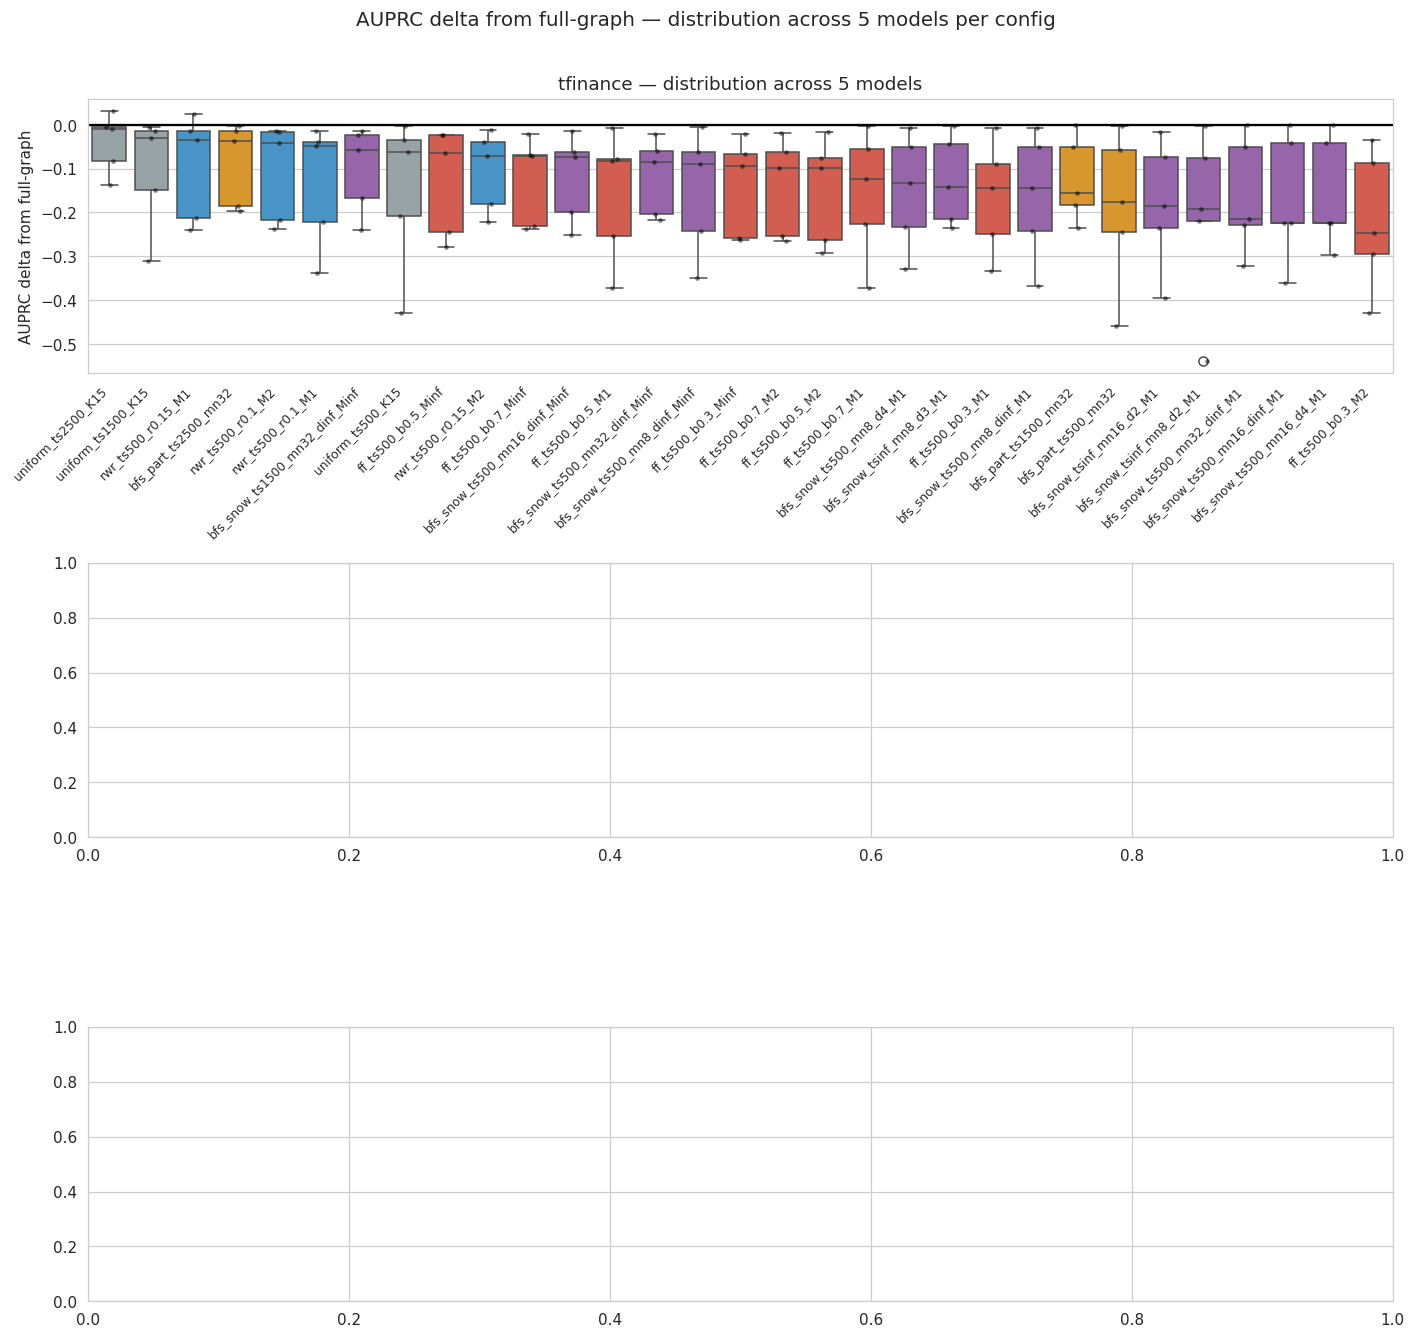

/tmp/ipykernel_2987391/1116796429.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='params_tag', y=metric_delta_col, order=order,
/tmp/ipykernel_2987391/1116796429.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)


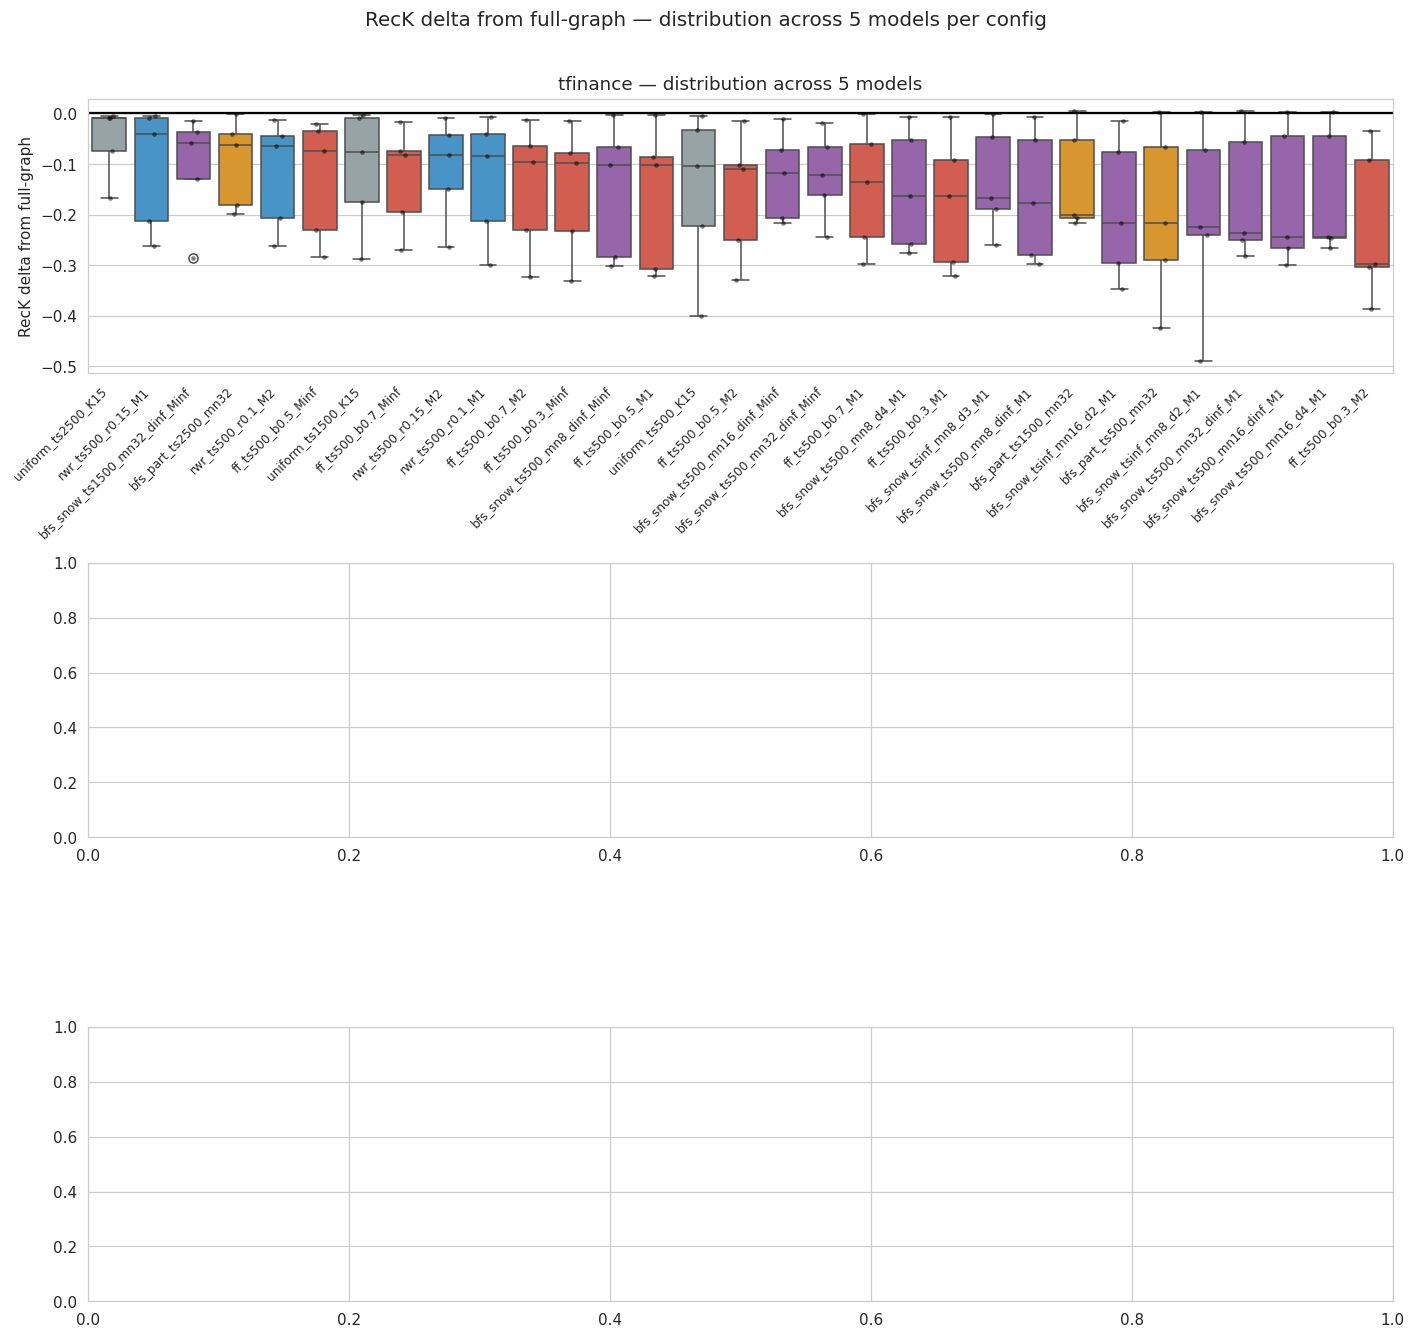

In [25]:
def _collective_box(metric_delta_col, metric_name, util_avg, ds, ax):
    sub = util_avg[util_avg['dataset'] == ds].copy()
    order = (sub.groupby('params_tag')[metric_delta_col].median()
                .sort_values(ascending=False).index.tolist())
    method_per_tag = dict(zip(sub['params_tag'], sub['method']))
    palette = [METHOD_COLORS[method_per_tag[t]] for t in order]
    sns.boxplot(data=sub, x='params_tag', y=metric_delta_col, order=order,
                palette=palette, ax=ax)
    sns.stripplot(data=sub, x='params_tag', y=metric_delta_col, order=order,
                  color='black', size=3, alpha=0.5, ax=ax)
    ax.axhline(0, color='black', linewidth=1.5)
    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel(f'{metric_name} delta from full-graph')
    ax.set_title(f'{ds} — distribution across 5 models')
    ax.grid(axis='x', visible=False)

for metric_col, metric_name in [('AUPRC_delta', 'AUPRC'), ('RecK_delta', 'RecK')]:
    fig, axes = plt.subplots(3, 1, figsize=(13, 12))
    for ax, ds in zip(axes, DATASETS):
        _collective_box(metric_col, metric_name, util_avg, ds, ax)
    fig.suptitle(f'{metric_name} delta from full-graph — distribution across 5 models per config',
                 y=1.01, fontsize=13)
    plt.tight_layout()
    fig.savefig(FIG / f'{metric_name.lower()}_delta_box.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Multiplicity-cap ablation — `forest_fire`

For each `(burn_prob, M)` cell, AUPRC and RecK *delta from full-graph baseline* (mean across 5 models). The grid swept `M ∈ {1, 2, ∞}`; M = 1 is disjoint (no node appears in more than one subgraph), M = ∞ is the existing pipeline default. M = 3 was not in this run; if you want it, add it to `grid.py:enumerate_configs` and rerun (`python run_grid.py --datasets ...` resumes from the existing CSV).

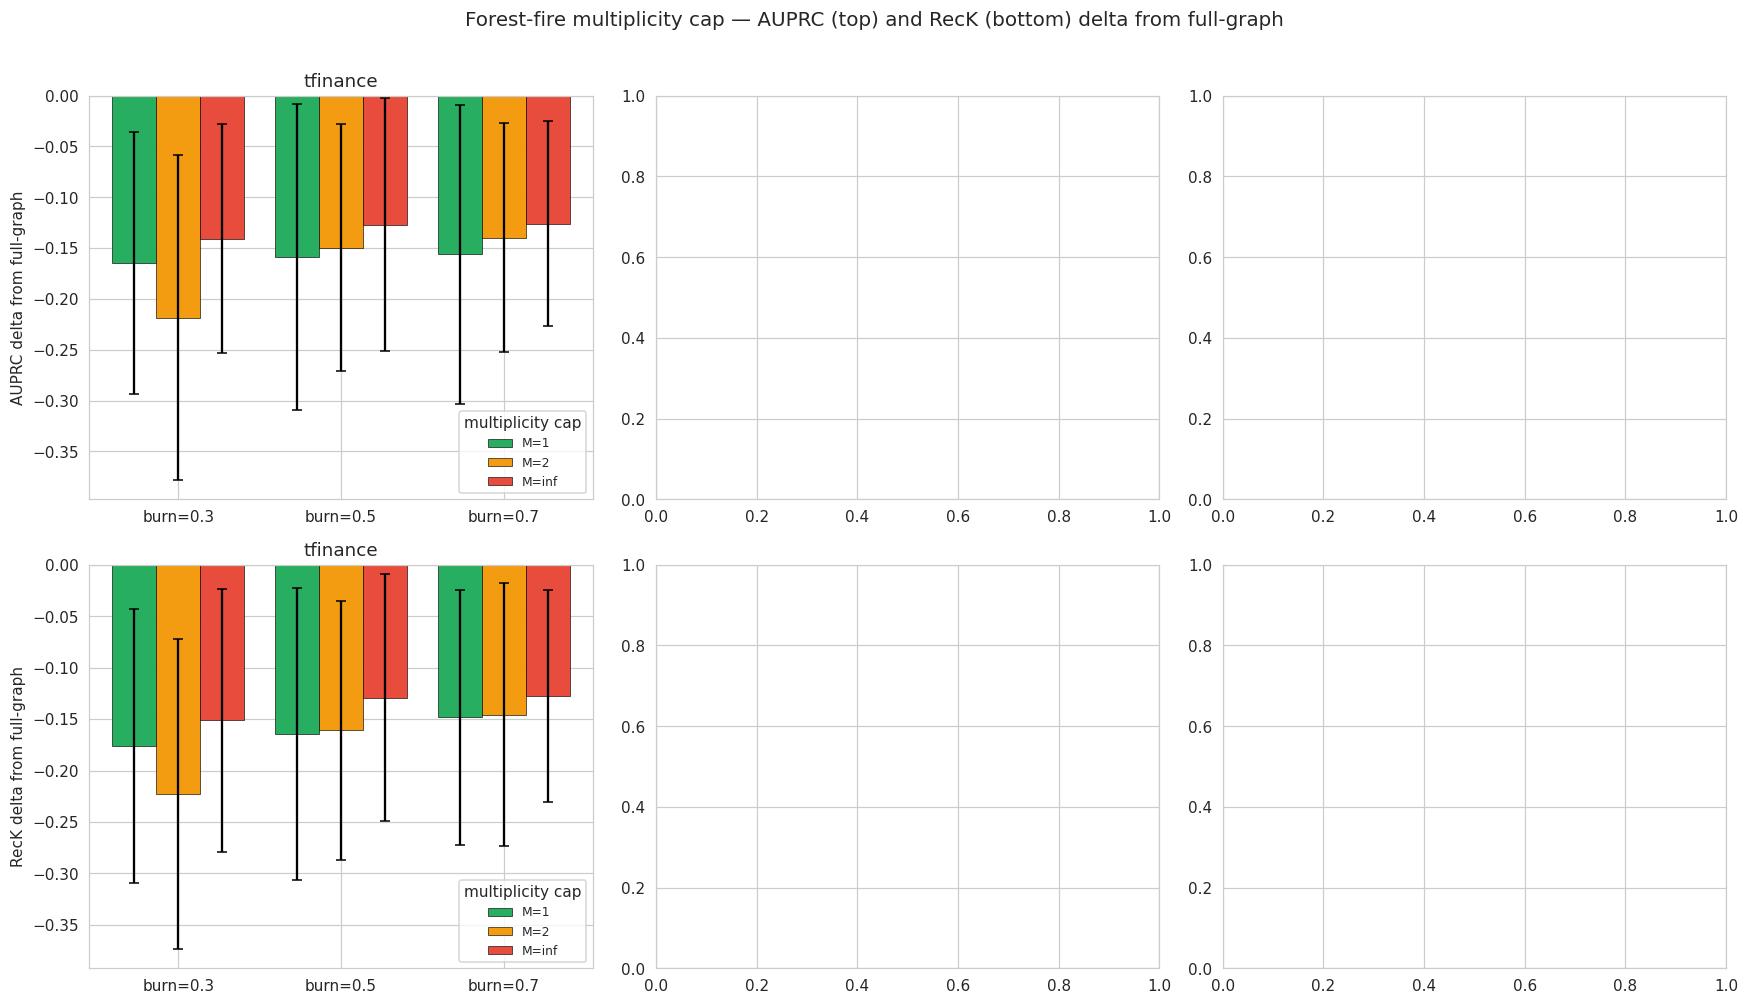

In [26]:
ff = util_avg[util_avg['method'] == 'forest_fire'].copy()
ff['burn_prob'] = ff['params_tag'].str.extract(r'b(\d+\.\d+)_').astype(float)
ff['M']         = ff['params_tag'].str.extract(r'M(\w+)$')[0]
M_ORDER = ['1', '2', 'inf']
M_COLORS = {'1': '#27ae60', '2': '#f39c12', 'inf': '#e74c3c'}

def _ff_panel(metric_delta_col, metric_name, ds, ax):
    sub = ff[ff['dataset'] == ds]
    pivot = sub.groupby(['burn_prob', 'M'])[metric_delta_col].mean().unstack('M')[M_ORDER]
    err   = sub.groupby(['burn_prob', 'M'])[metric_delta_col].std().unstack('M')[M_ORDER]
    x = np.arange(len(pivot))
    width = 0.27
    for i, M in enumerate(M_ORDER):
        ax.bar(x + (i - 1) * width, pivot[M], width=width, yerr=err[M], capsize=3,
               color=M_COLORS[M], label=f'M={M}',
               edgecolor='black', linewidth=0.4)
    ax.axhline(0, color='black', linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels([f'burn={b}' for b in pivot.index])
    ax.set_ylabel(f'{metric_name} delta from full-graph')
    ax.set_title(f'{ds}')
    ax.legend(title='multiplicity cap', fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, ds in zip(axes[0], DATASETS):
    _ff_panel('AUPRC_delta', 'AUPRC', ds, ax)
for ax, ds in zip(axes[1], DATASETS):
    _ff_panel('RecK_delta', 'RecK', ds, ax)
fig.suptitle('Forest-fire multiplicity cap — AUPRC (top) and RecK (bottom) delta from full-graph',
             y=1.01, fontsize=13)
plt.tight_layout()
fig.savefig(FIG / 'mcap_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Structural fidelity per config

How faithful each config's sample is to the source graph it was drawn from. Reference (full graph): coverage = 1.0, prior_shift = 0.0, deg_ratio = 1.0.

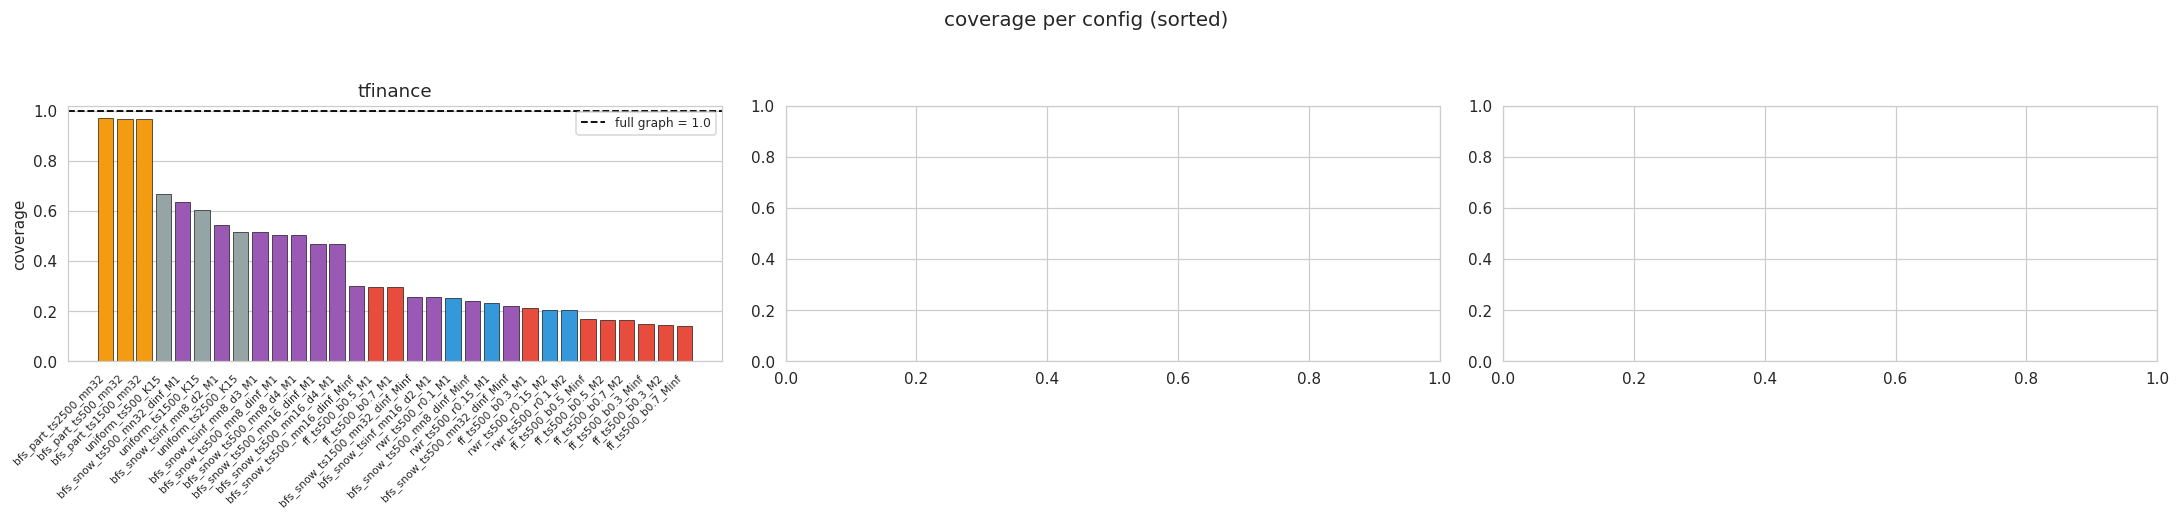

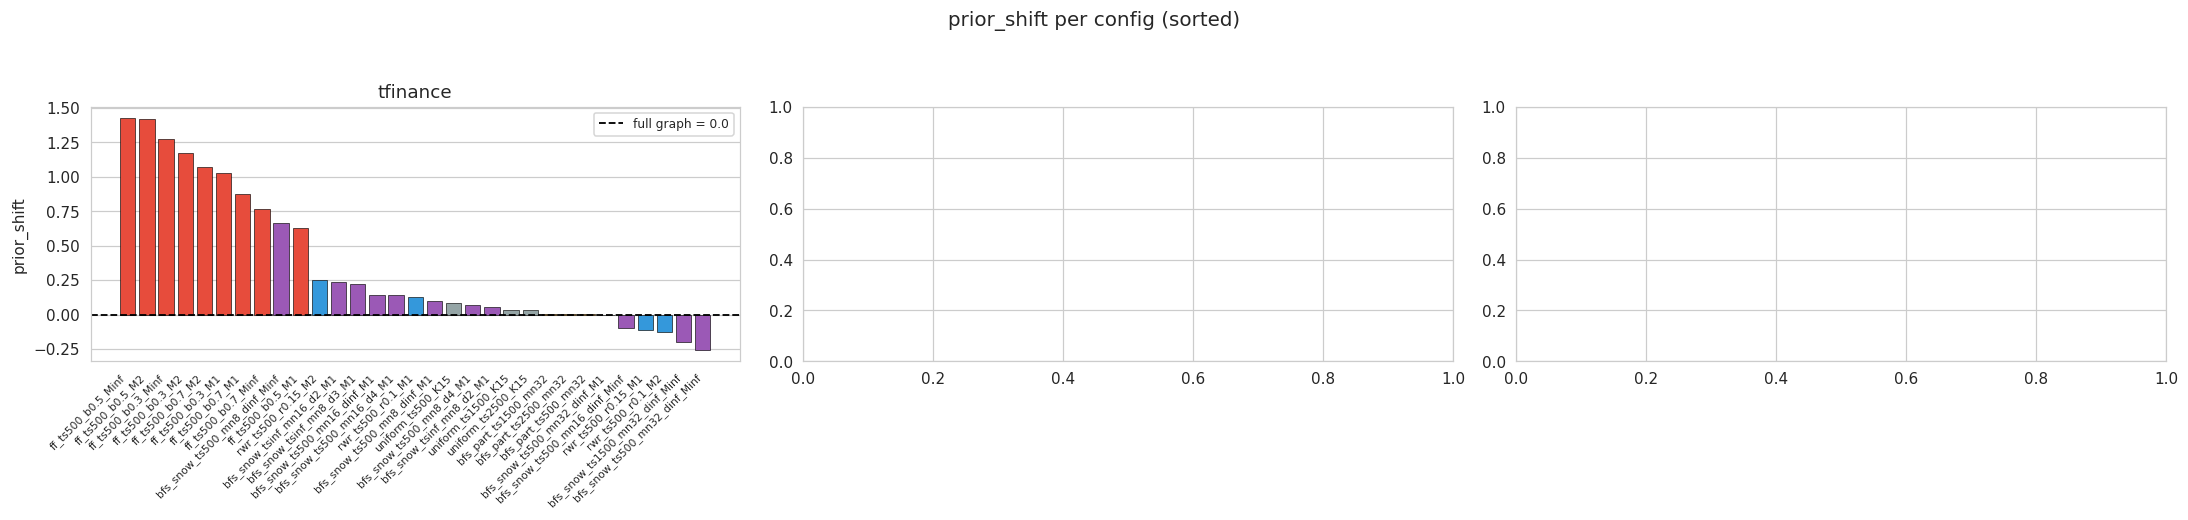

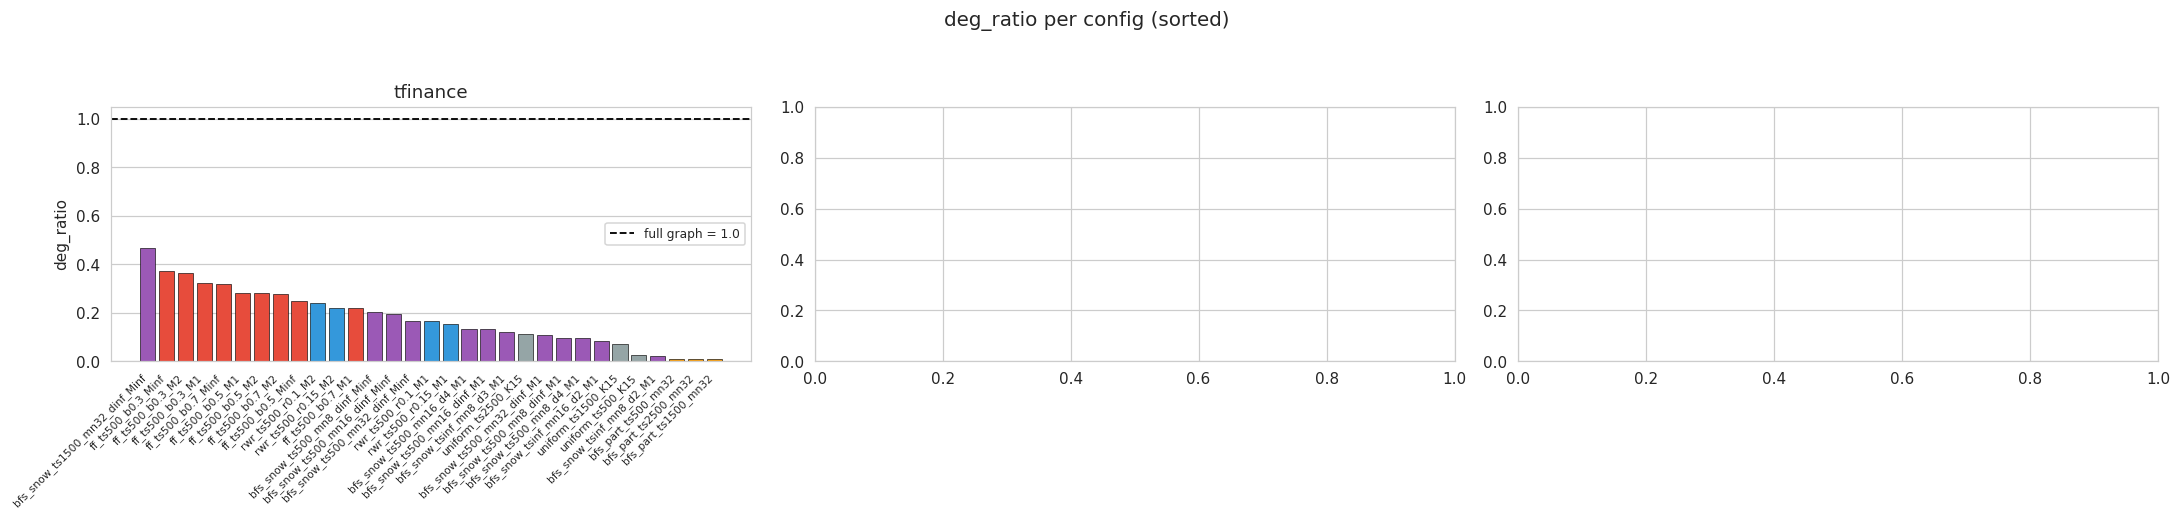

In [27]:
struct_avg = (struct.groupby(['dataset', 'method', 'params_tag'])
                    [['coverage', 'prior_shift', 'deg_ratio',
                      'multiplicity_max', 'multiplicity_p95']]
                    .mean().reset_index())

def _struct_panel(col, ref, ds, ax, sort_desc=True):
    sub = struct_avg[struct_avg['dataset'] == ds].copy()
    sub = sub.sort_values(col, ascending=not sort_desc)
    colors = [METHOD_COLORS[m] for m in sub['method']]
    ax.bar(range(len(sub)), sub[col], color=colors, edgecolor='black', linewidth=0.4)
    if ref is not None:
        ax.axhline(ref, color='black', linewidth=1.2, linestyle='--',
                   label=f'full graph = {ref}')
        ax.legend(fontsize=8)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['params_tag'], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel(col)
    ax.set_title(f'{ds}')
    ax.grid(axis='x', visible=False)

for col, ref in [('coverage', 1.0), ('prior_shift', 0.0), ('deg_ratio', 1.0)]:
    fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
    for ax, ds in zip(axes, DATASETS):
        _struct_panel(col, ref, ds, ax)
    fig.suptitle(f'{col} per config (sorted)', y=1.04, fontsize=13)
    plt.tight_layout()
    fig.savefig(FIG / f'struct_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7b. Sample budget per config — number and size of subgraphs

How big is each method's sample budget? `num_subgraphs` is the partition count K; `mean_size` is the average node count per partition. Their product (≈ `total_nodes`, modulo overlap) is what the downstream classifier sees per epoch — useful sanity check when comparing utility deltas across methods that differ in budget.

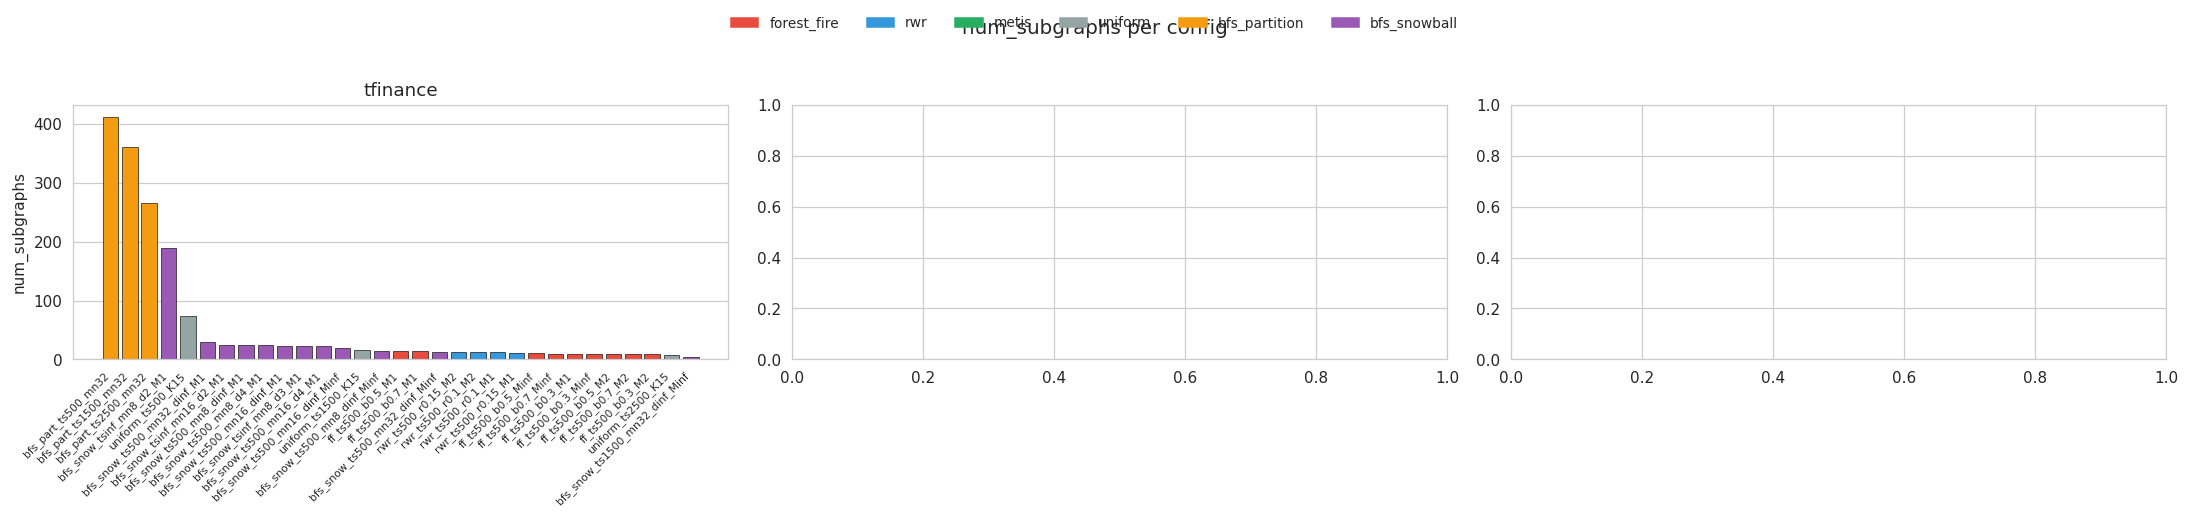

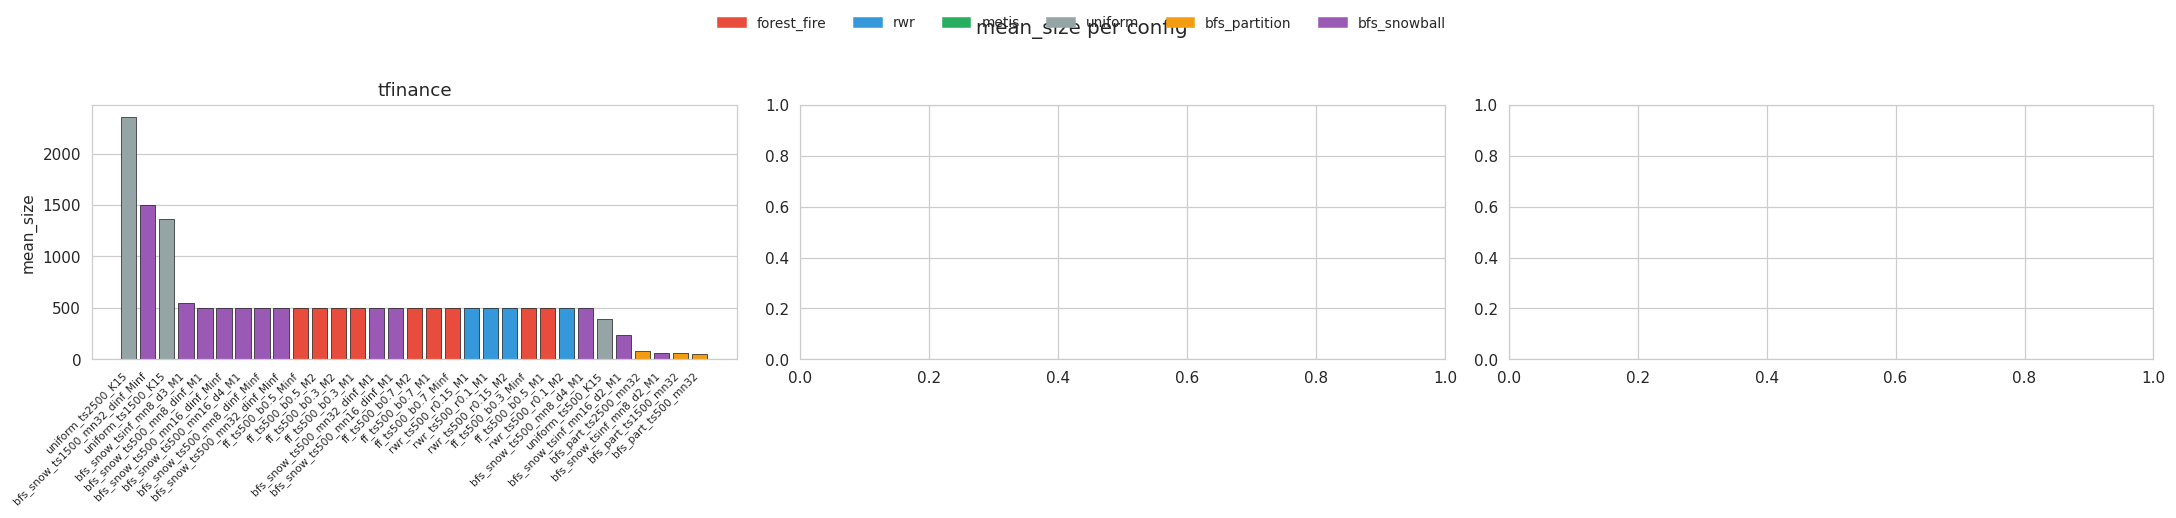

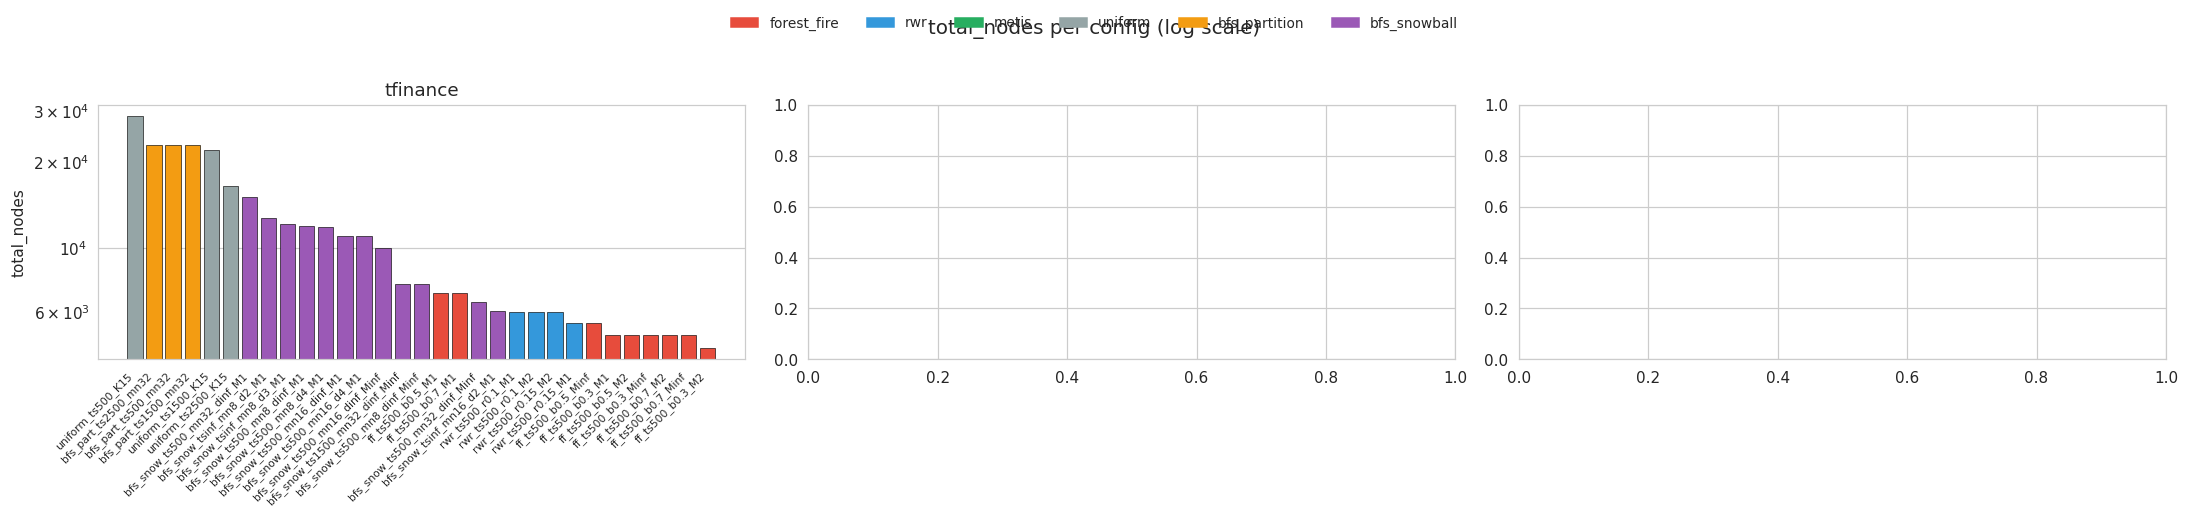

In [28]:
budget = (struct.groupby(['dataset', 'method', 'params_tag'])
                [['num_subgraphs', 'mean_size', 'total_nodes']]
                .mean().reset_index())

def _budget_panel(col, ds, ax, log=False):
    sub = budget[budget['dataset'] == ds].copy().sort_values(col, ascending=False)
    colors = [METHOD_COLORS[m] for m in sub['method']]
    ax.bar(range(len(sub)), sub[col], color=colors, edgecolor='black', linewidth=0.4)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['params_tag'], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel(col)
    ax.set_title(f'{ds}')
    if log:
        ax.set_yscale('log')
    ax.grid(axis='x', visible=False)

for col, log in [('num_subgraphs', False), ('mean_size', False), ('total_nodes', True)]:
    fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
    for ax, ds in zip(axes, DATASETS):
        _budget_panel(col, ds, ax, log=log)
    handles = [mpatches.Patch(color=c, label=m) for m, c in METHOD_COLORS.items()]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=len(METHOD_COLORS), fontsize=9, frameon=False)
    suffix = ' (log scale)' if log else ''
    fig.suptitle(f'{col} per config{suffix}', y=1.02, fontsize=13)
    plt.tight_layout()
    fig.savefig(FIG / f'budget_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7c. Per-partition size range per config

Within a single run, K partitions are drawn — this shows the *within-config* spread of node counts: median (`mean_size`), IQR (`size_p25`–`size_p75`), and full range (`size_min`–`size_max`). Methods like `metis` should produce tight bands (balanced cuts); `forest_fire` and `rwr` will be wider (size depends on burn dynamics).

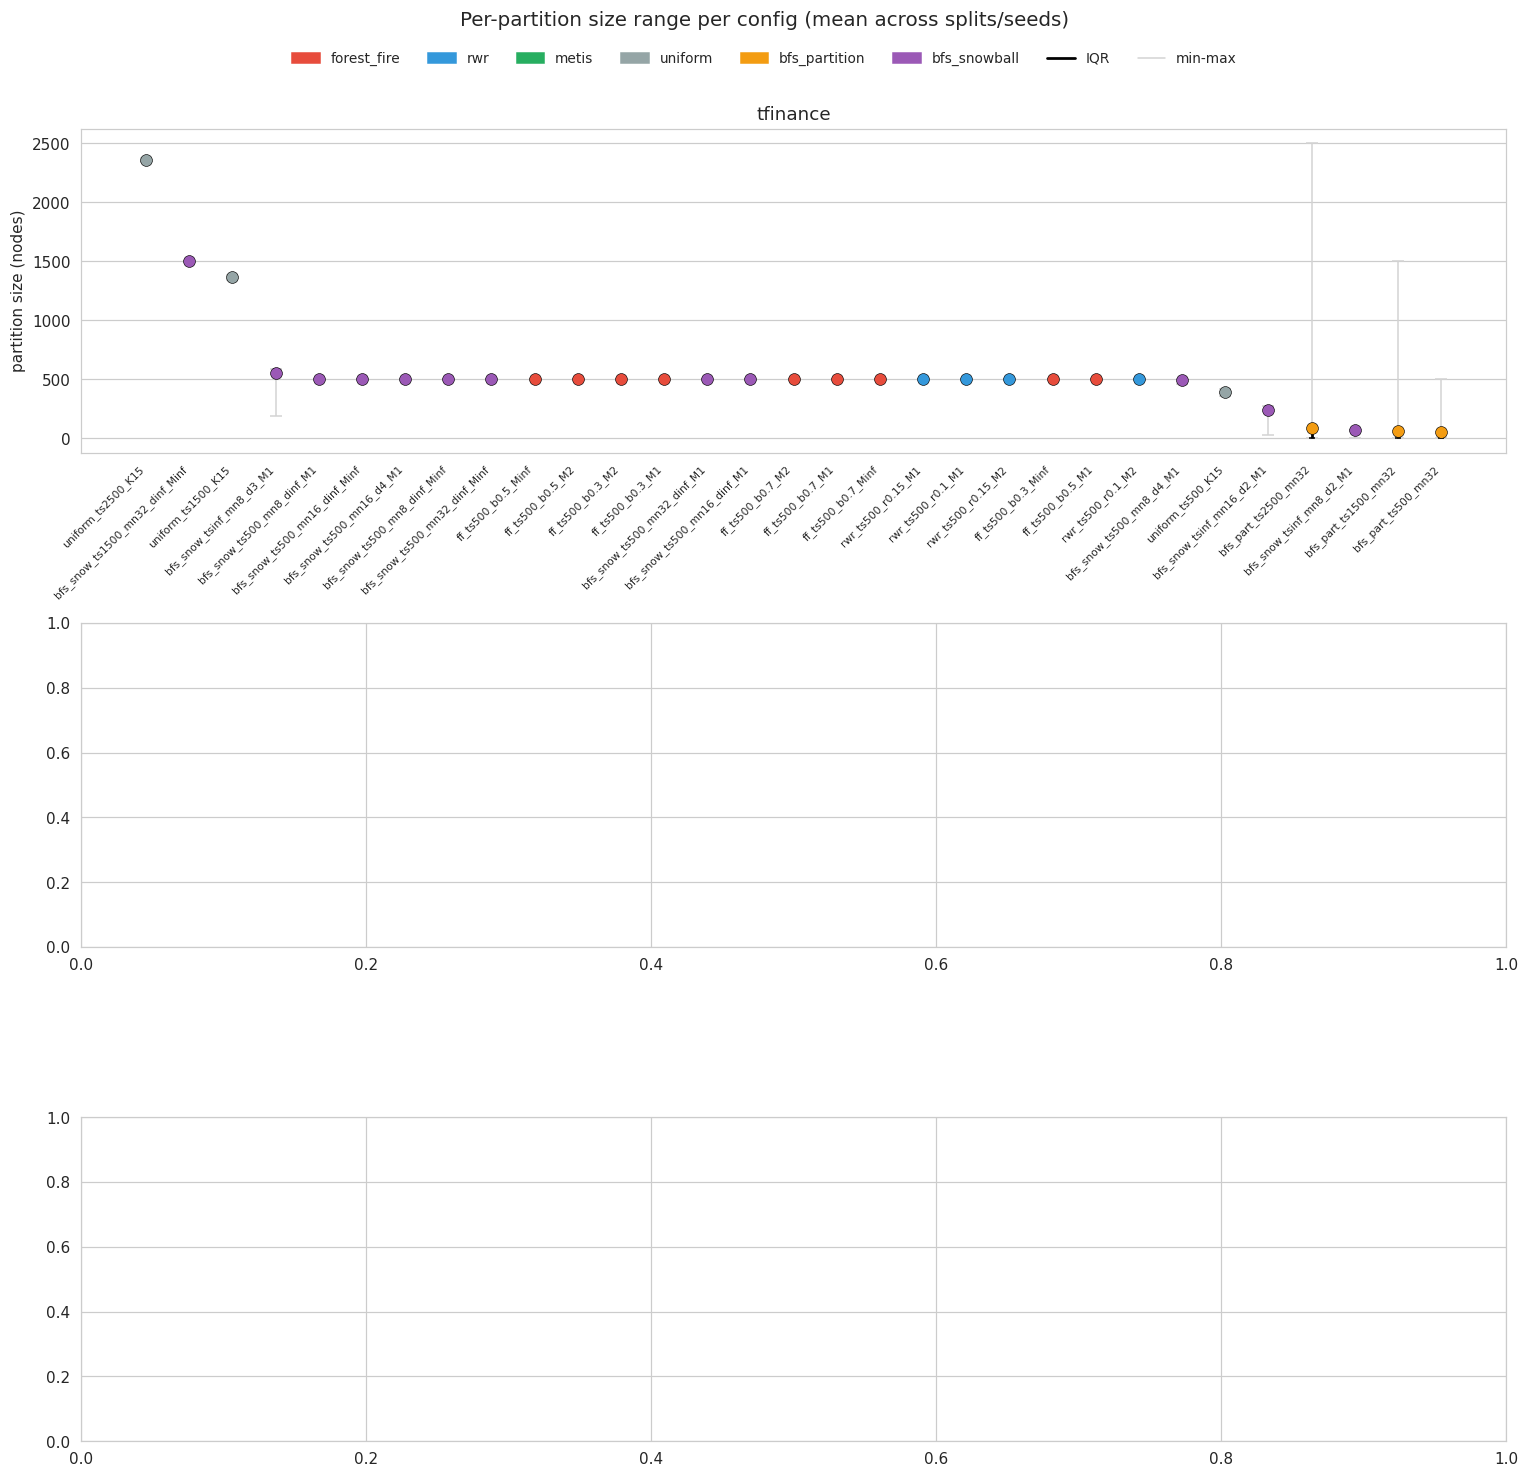

In [29]:
size_cols = ['size_min', 'size_p25', 'mean_size', 'size_p75', 'size_max']
missing = [c for c in size_cols if c not in struct.columns]
if missing:
    print(f'NOTE: structure.csv is missing {missing}. Re-run the grid (delete artifacts/grid/structure.csv first) to populate per-partition size percentiles.')
else:
    size_avg = (struct.groupby(['dataset', 'method', 'params_tag'])[size_cols]
                      .mean().reset_index())

    def _size_panel(ds, ax):
        sub = size_avg[size_avg['dataset'] == ds].copy().sort_values('mean_size', ascending=False)
        x = np.arange(len(sub))
        colors = [METHOD_COLORS[m] for m in sub['method']]
        full_range_lo = np.maximum(0, sub['mean_size'] - sub['size_min'])
        full_range_hi = np.maximum(0, sub['size_max'] - sub['mean_size'])
        iqr_lo = np.maximum(0, sub['mean_size'] - sub['size_p25'])
        iqr_hi = np.maximum(0, sub['size_p75'] - sub['mean_size'])
        ax.errorbar(x, sub['mean_size'],
                    yerr=[full_range_lo, full_range_hi],
                    fmt='none', ecolor='lightgray', capsize=4, linewidth=1, label='min-max')
        ax.errorbar(x, sub['mean_size'],
                    yerr=[iqr_lo, iqr_hi],
                    fmt='none', ecolor='black', capsize=2, linewidth=1.8, label='IQR')
        for xi, m, ms in zip(x, sub['method'], sub['mean_size']):
            ax.scatter(xi, ms, s=60, color=METHOD_COLORS[m], edgecolor='black', linewidth=0.4, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(sub['params_tag'], rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('partition size (nodes)')
        ax.set_title(f'{ds}')
        ax.grid(axis='x', visible=False)

    fig, axes = plt.subplots(3, 1, figsize=(14, 13))
    for ax, ds in zip(axes, DATASETS):
        _size_panel(ds, ax)
    handles = [mpatches.Patch(color=c, label=m) for m, c in METHOD_COLORS.items()]
    handles += [plt.Line2D([0], [0], color='black', linewidth=1.8, label='IQR'),
                plt.Line2D([0], [0], color='lightgray', linewidth=1, label='min-max')]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.01),
               ncol=len(METHOD_COLORS) + 2, fontsize=9, frameon=False)
    fig.suptitle('Per-partition size range per config (mean across splits/seeds)', y=1.03, fontsize=13)
    plt.tight_layout()
    fig.savefig(FIG / 'size_range_per_config.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Fidelity vs utility scatter

AUPRC delta (across-models mean) vs each structural metric. Visual question: which fidelity dimension *predicts* utility recovery?

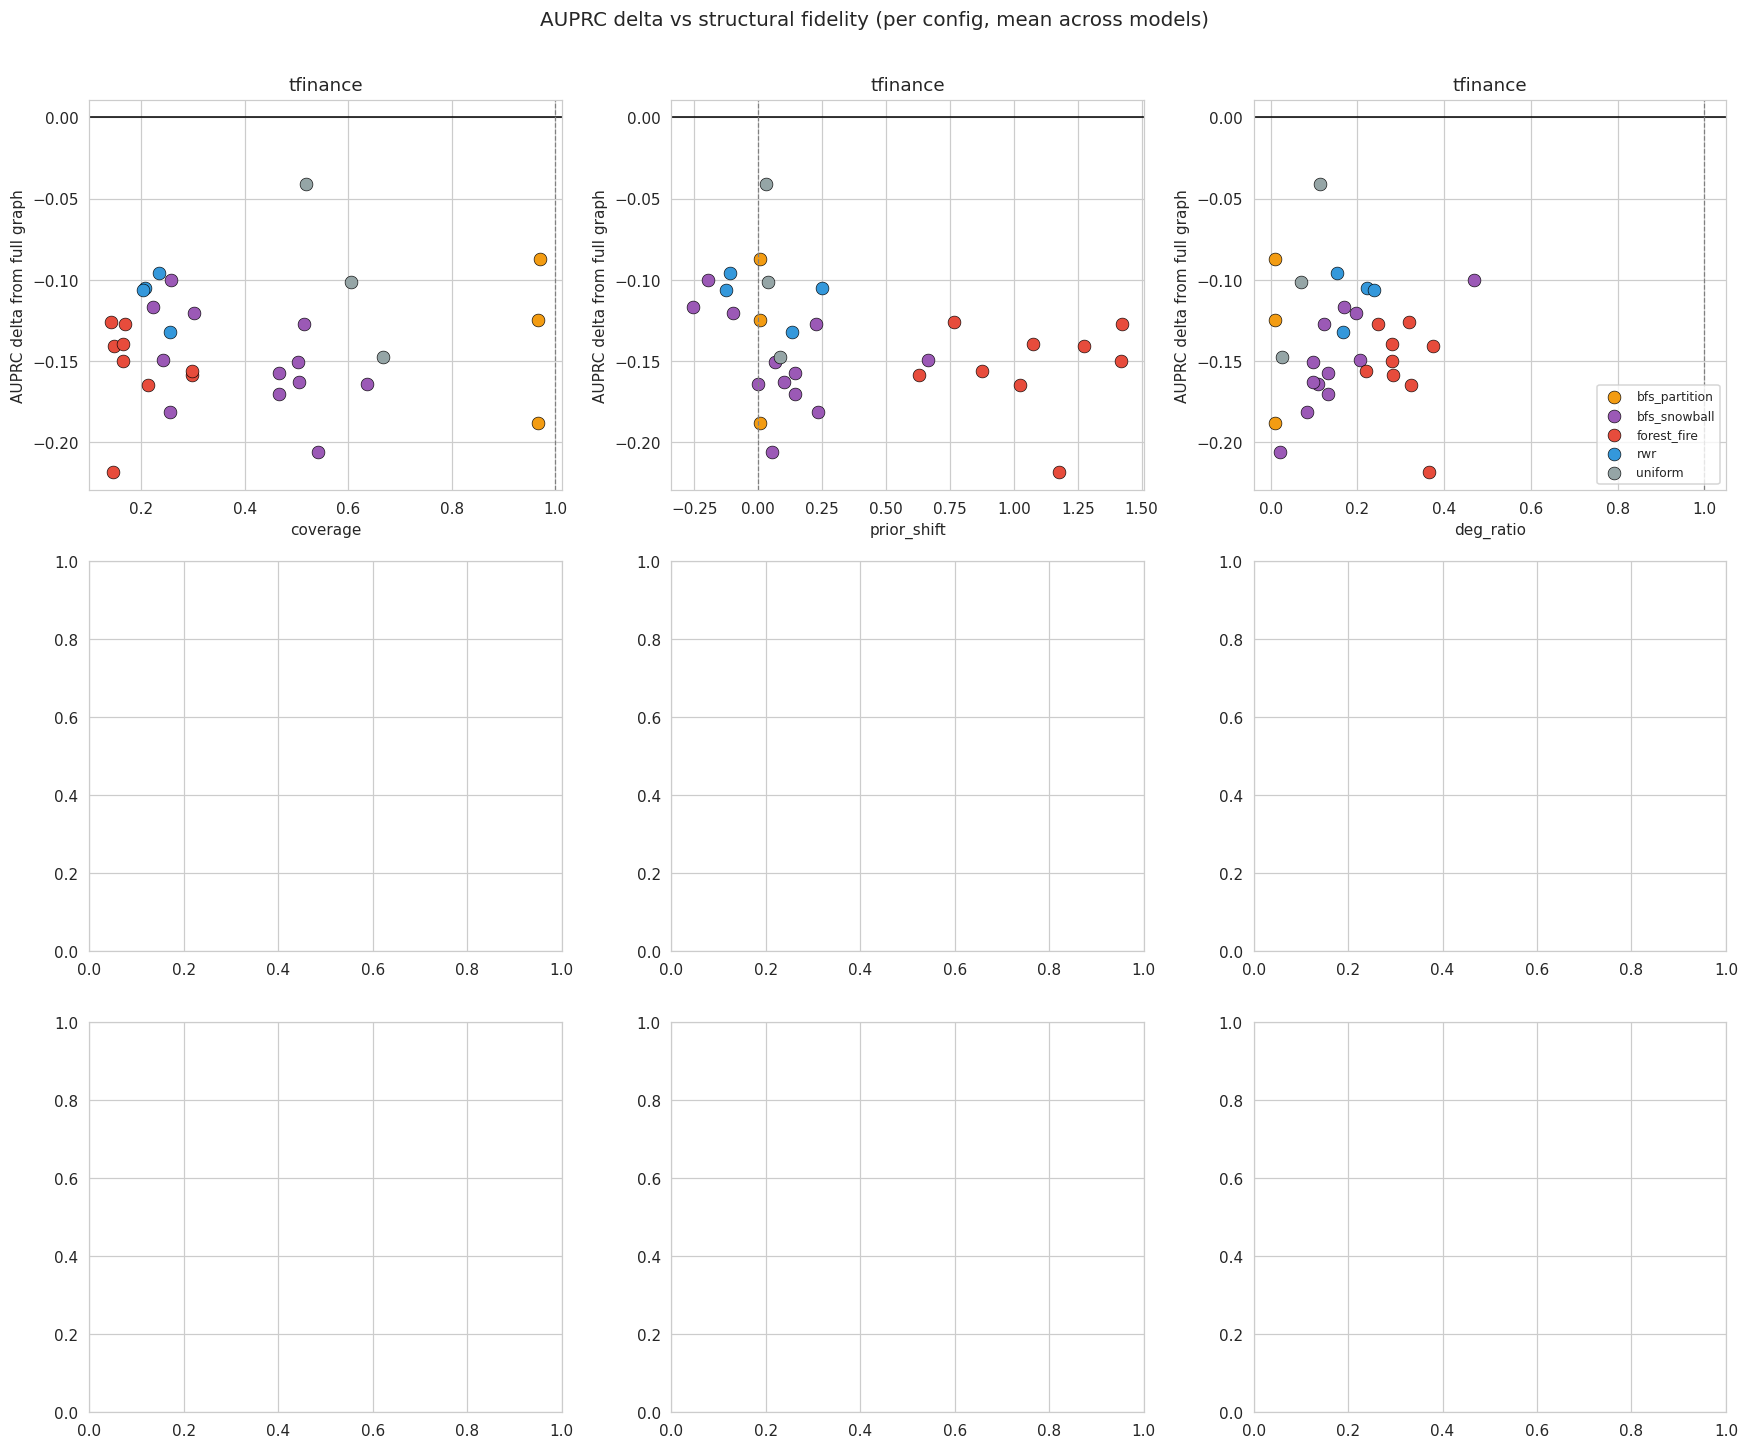

In [30]:
scatter_df = (util_avg.groupby(['dataset', 'method', 'params_tag'])
                       [['AUPRC_delta', 'RecK_delta']].mean().reset_index()
                       .merge(struct_avg, on=['dataset', 'method', 'params_tag']))

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for row_i, ds in enumerate(DATASETS):
    sub = scatter_df[scatter_df['dataset'] == ds]
    for col_i, x in enumerate(['coverage', 'prior_shift', 'deg_ratio']):
        ax = axes[row_i, col_i]
        for method, msub in sub.groupby('method'):
            ax.scatter(msub[x], msub['AUPRC_delta'],
                       s=70, color=METHOD_COLORS[method],
                       label=method, edgecolor='black', linewidth=0.4)
        ax.axhline(0, color='black', linewidth=1)
        if x == 'prior_shift':
            ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
        else:
            ax.axvline(1, color='gray', linewidth=0.8, linestyle='--')
        ax.set_xlabel(x)
        ax.set_ylabel('AUPRC delta from full graph')
        ax.set_title(f'{ds}')
        if row_i == 0 and col_i == 2:
            ax.legend(fontsize=8, loc='best')
fig.suptitle('AUPRC delta vs structural fidelity (per config, mean across models)',
             y=1.01, fontsize=13)
plt.tight_layout()
fig.savefig(FIG / 'fidelity_vs_utility.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Top configs per dataset (sorted by AUPRC delta)

Concrete recommendations. Best `AUPRC_delta` = closest to (or above) the full-graph baseline.

In [31]:
config_means = (util_avg.groupby(['dataset', 'method', 'params_tag'])
                          [['AUPRC_delta', 'RecK_delta']]
                          .mean().reset_index())
winners = (config_means.sort_values(['dataset', 'AUPRC_delta'], ascending=[True, False])
                       .groupby('dataset').head(5))
winners.merge(struct_avg, on=['dataset', 'method', 'params_tag']).round(3)

,dataset,method,params_tag,AUPRC_delta,RecK_delta,coverage,prior_shift,deg_ratio,multiplicity_max,multiplicity_p95
0,amazon,bfs_snowball,bfs_snow_tsinf_mn8_d3_M1,0.015,0.012,0.729,-0.325,0.176,1.0,1.0
1,amazon,rwr,rwr_ts500_r0.1_M1,0.015,0.022,0.796,-0.248,0.138,1.0,1.0
2,amazon,uniform,uniform_ts500_K15,0.007,0.015,0.905,-0.048,0.073,9.2,5.0
3,amazon,forest_fire,ff_ts500_b0.3_M1,-0.007,-0.006,0.724,-0.298,0.170,1.0,1.0
4,amazon,bfs_partition,bfs_part_ts500_mn32,-0.007,0.007,0.984,-0.034,0.049,1.0,1.0
5,questions,metis,metis_K5,-0.003,-0.001,0.919,0.024,0.706,1.0,1.0
6,questions,metis,metis_K15,-0.004,0.001,0.976,0.007,0.549,1.0,1.0
7,questions,bfs_partition,bfs_part_ts2500_mn32,-0.012,-0.011,0.490,0.335,0.226,1.0,1.0
8,questions,bfs_partition,bfs_part_ts500_mn32,-0.012,-0.010,0.483,0.316,0.230,1.0,1.0
9,questions,bfs_partition,bfs_part_ts1500_mn32,-0.016,-0.014,0.486,0.313,0.227,1.0,1.0


## 10. Top-10 candidates — exact per-partition sizes

For each dataset, take the top-`TOP_N` configs by mean `AUPRC_delta` and load the persisted `split0.pkl` to list every partition's `(n, m)`. Surfaces the trivial 2–4-node remnants that the aggregate `mean_size` view hides.

In [32]:
import pickle as _pickle
pd.set_option('display.max_colwidth', None)
PICKLE_ROOT = HERE.parent.parent / 'datasets' / 'bigg_subsamples'
TOP_N    = 10
SPLIT_ID = 0   # partitions are split-stable; one split is representative

_config_means = (util_avg.groupby(['dataset', 'method', 'params_tag'])
                         [['AUPRC_delta', 'RecK_delta']]
                         .mean().reset_index())
_top = (_config_means.sort_values(['dataset', 'AUPRC_delta'], ascending=[True, False])
                     .groupby('dataset').head(TOP_N))
print('Hello')
_rows = []
for _, r in _top.iterrows():
    ds, tag = r['dataset'], r['params_tag']
    pkl = PICKLE_ROOT / ds / tag / f'split{SPLIT_ID}.pkl'
    if not pkl.exists():
        _rows.append({'dataset': ds, 'params_tag': tag,
                      'AUPRC_delta': round(r['AUPRC_delta'], 4),
                      'K': None, 'sizes_n': '(pickle missing)'})
        continue
    if ds in DATASETS:
        with open(pkl, 'rb') as f:
            parts = _pickle.load(f)['partitions']
        ns = [g.number_of_nodes() for g, _, _ in parts]
        ms = [g.number_of_edges() for g, _, _ in parts]
        print(ds)
        _rows.append({
            'dataset': ds, 'params_tag': tag,
            'AUPRC_delta': round(r['AUPRC_delta'], 4),
            'K': len(parts),
            'n_min': min(ns), 'n_med': int(np.median(ns)), 'n_max': max(ns),
            'm_med': int(np.median(ms)), 'm_max': max(ms),
            'sizes_n': ', '.join(str(n) for n in ns),
        })

top_sizes = pd.DataFrame(_rows)
top_sizes

Hello
tfinance
tfinance
tfinance
tfinance
tfinance
tfinance
tfinance
tfinance
tfinance
tfinance


,dataset,params_tag,AUPRC_delta,K,n_min,n_med,n_max,m_med,m_max,sizes_n
0,tfinance,uniform_ts2500_K15,-0.0408,7,2353,2364,2375,84683,92847,"2364, 2358, 2375, 2356, 2353, 2368, 2372"
1,tfinance,bfs_part_ts2500_mn32,-0.0869,257,2,2,2500,1,402877,"2500, 2500, 2500, 2500, 2500, 2500, 3, 2500, 2500, 2123, 6, 2, 2, 61, 6, 6, 5, 4, 2, 2, 2, 6, 2, 3, 5, 18, 4, 2, 5, 7, 2, 3, 4, 3, 2, 3, 9, 4, 2, 5, 3, 3, 2, 3, 2, 3, 2, 4, 12, 3, 4, 3, 2, 2, 4, 3, 4, 8, 5, 3, 2, 3, 2, 2, 5, 3, 2, 2, 2, 7, 2, 2, 2, 2, 3, 2, 2, 5, 3, 3, 2, 2, 2, 2, 2, 4, 2, 6, 2, 2, 2, 5, 5, 2, 4, 2, 2, 2, 2, 3, 3, 4, 2, 3, 2, 2, 2, 2, 4, 4, 3, 2, 4, 2, 2, 2, 2, 4, 2, 3, 2, 4, 2, 2, 4, 2, 2, 3, 2, 2, 2, 2, 3, 4, 2, 3, 2, 2, 6, 2, 3, 4, 6, 3, 4, 3, 2, 5, 2, 2, 2, 8, 3, 2, 3, 2, 3, 2, 9, 4, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 4, 2, 3, 3, 2, 2, 3, 2, 3, 2, 6, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 3, 2, 2, 2, 3, 6, 3, 2, 2, 3, 3, 2, 2, 2, 2, 4, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2"
2,tfinance,rwr_ts500_r0.15_M1,-0.0955,11,500,500,500,24591,48856,"500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500"
3,tfinance,bfs_snow_ts1500_mn32_dinf_Minf,-0.1000,5,1500,1500,1500,166884,863350,"1500, 1500, 1500, 1500, 1500"
4,tfinance,uniform_ts1500_K15,-0.1013,16,1347,1369,1391,31705,35360,"1368, 1384, 1361, 1369, 1370, 1370, 1347, 1369, 1354, 1384, 1373, 1370, 1364, 1384, 1368, 1391"
5,tfinance,rwr_ts500_r0.15_M2,-0.1048,12,500,500,500,32149,97124,"500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500"
6,tfinance,rwr_ts500_r0.1_M2,-0.1060,12,500,500,500,29670,87120,"500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500"
7,tfinance,bfs_snow_ts500_mn32_dinf_Minf,-0.1170,13,500,500,500,19224,116158,"500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500"
8,tfinance,bfs_snow_ts500_mn16_dinf_Minf,-0.1206,20,500,500,500,16813,110528,"500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500"
9,tfinance,bfs_part_ts1500_mn32,-0.1245,357,2,2,1500,1,984537,"1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 1500, 2, 1500, 1500, 608, 7, 61, 4, 2, 12, 5, 3, 8, 4, 2, 3, 2, 3, 3, 5, 2, 5, 4, 5, 5, 2, 2, 6, 9, 2, 2, 10, 20, 6, 3, 15, 7, 3, 11, 4, 2, 4, 9, 4, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 18, 3, 4, 2, 3, 2, 3, 3, 4, 5, 7, 6, 2, 2, 2, 2, 4, 7, 2, 2, 5, 2, 2, 6, 3, 4, 5, 2, 3, 3, 2, 3, 2, 2, 4, 3, 8, 6, 4, 4, 2, 2, 9, 3, 2, 2, 2, 7, 3, 3, 4, 10, 5, 3, 2, 2, 2, 3, 6, 2, 2, 2, 2, 2, 5, 2, 4, 2, 3, 2, 2, 3, 4, 2, 3, 13, 5, 2, 2, 2, 3, 2, 7, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 3, 2, 3, 3, 2, 4, 6, 5, 2, 2, 4, 3, 2, 3, 3, 2, 4, 4, 2, 5, 2, 7, 4, 4, 6, 2, 2, 2, 2, 4, 4, 3, 3, 6, 2, 2, 6, 3, 2, 4, 4, 2, 5, 2, 8, 2, 2, 2, 2, 3, 4, 3, 2, 4, 2, 2, 5, 4, 3, 5, 2, 2, 4, 2, 7, 2, 4, 2, 3, 4, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 4, 2, 4, 2, 3, 2, 4, 5, 2, 2, 3, 2, 4, 2, 3, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 3, 5, 2, 3, 8, 2, 3, 2, 3, 3, 2, 2, 2, 2, 5, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 4, 2, 2, 2, 3, 5, 2, 2, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2"


In [34]:
top_sizes[top_sizes['dataset'] == 'tfinance'].to_latex()

'\\begin{tabular}{lllrrrrrrrl}\n\\toprule\n & dataset & params_tag & AUPRC_delta & K & n_min & n_med & n_max & m_med & m_max & sizes_n \\\\\n\\midrule\n0 & tfinance & uniform_ts2500_K15 & -0.040800 & 7 & 2353 & 2364 & 2375 & 84683 & 92847 & 2364, 2358, 2375, 2356, 2353, 2368, 2372 \\\\\n1 & tfinance & bfs_part_ts2500_mn32 & -0.086900 & 257 & 2 & 2 & 2500 & 1 & 402877 & 2500, 2500, 2500, 2500, 2500, 2500, 3, 2500, 2500, 2123, 6, 2, 2, 61, 6, 6, 5, 4, 2, 2, 2, 6, 2, 3, 5, 18, 4, 2, 5, 7, 2, 3, 4, 3, 2, 3, 9, 4, 2, 5, 3, 3, 2, 3, 2, 3, 2, 4, 12, 3, 4, 3, 2, 2, 4, 3, 4, 8, 5, 3, 2, 3, 2, 2, 5, 3, 2, 2, 2, 7, 2, 2, 2, 2, 3, 2, 2, 5, 3, 3, 2, 2, 2, 2, 2, 4, 2, 6, 2, 2, 2, 5, 5, 2, 4, 2, 2, 2, 2, 3, 3, 4, 2, 3, 2, 2, 2, 2, 4, 4, 3, 2, 4, 2, 2, 2, 2, 4, 2, 3, 2, 4, 2, 2, 4, 2, 2, 3, 2, 2, 2, 2, 3, 4, 2, 3, 2, 2, 6, 2, 3, 4, 6, 3, 4, 3, 2, 5, 2, 2, 2, 8, 3, 2, 3, 2, 3, 2, 9, 4, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 4, 2, 3, 3, 2, 2, 3, 2, 3, 2, 6, 2, 2, 2, 3, 2, 2, 2, 3